

3. Für NDCG

Hier würde ich unbedingt Järvelin & Kekäläinen (2002) ergänzen. Das ist die klassische Quelle für Discounted/Cumulative Gain und NDCG. Liu (2009) erklärt Learning-to-Rank insgesamt, aber Järvelin & Kekäläinen ist die Originalquelle für die Metrik.

# Explainable Boosting Machines (EBM)

## Warum EBM?

**Methodische Begründung für den Einsatz von EBM**

**Inhärente Interpretierbarkeit durch GA²M-Strukturen**  
Im Gegensatz zu komplexen Black-Box-Modellen, wie tiefen neuronalen Netzen oder stark verschachtelten Boosting-Verfahren, deren Nachvollziehbarkeit häufig erst durch Post-hoc-Erklärungsmethoden wie SHAP hergestellt wird, gehören Explainable Boosting Machines (EBM) zur Klasse inhärent interpretierbarer Glass-Box-Modelle (vgl. Nori et al., 2019, S. 1–3). Die algorithmische Grundlage der EBM bilden verallgemeinerte additive Modelle, die optional um paarweise Interaktionseffekte erweitert werden können (GA²M) (vgl. Lou et al., 2013, S. 623). Die zugrundeliegende Modellstruktur lässt sich formal wie folgt darstellen:

$$g(E[y]) = \beta_0 + \sum_i f_i(x_i) + \sum_{i,j} f_{ij}(x_i, x_j)$$

(vgl. Lou et al., 2013, S. 623). Hierbei werden univariate Haupteffekte \(f_i\) sowie optionale zweidimensionale Interaktionseffekte \(f_{ij}\) separat gelernt und anschließend additiv kombiniert (vgl. Lou et al., 2012, S. 152; Nori et al., 2019, S. 3). Dadurch bleibt nachvollziehbar, welche Merkmale und Interaktionen zur Modellentscheidung beitragen. Gegenüber klassischen Black-Box-Modellen bietet EBM somit eine deutlich höhere Transparenz, ohne vollständig auf nicht-lineare Modellierungsmöglichkeiten verzichten zu müssen.

**Erfassung multikausaler und nicht-linearer Sport-Muster**  
Die Prognose von Rennergebnissen im professionellen Straßenradsport stellt eine komplexe algorithmische Herausforderung dar, da die sportliche Leistung von einer Vielzahl interner Faktoren, wie dem physiologischen Profil oder der aktuellen Form eines Fahrers, sowie externer Faktoren, wie Wetterbedingungen, Streckenprofil, Teamstrategie, Defekten oder Stürzen, beeinflusst wird (vgl. Kholkine et al., 2021, S. 1–2; Kholkine et al., 2020, S. 103). Diese Faktoren wirken häufig nicht isoliert, sondern entfalten ihre Bedeutung erst im Zusammenspiel mit weiteren Renn- und Fahrermerkmalen.

EBMs sind für diesen Kontext besonders geeignet, da sie nicht-lineare und stufenförmige Zusammenhänge modellieren können, ohne die globale Interpretierbarkeit vollständig aufzugeben (vgl. Lou et al., 2013, S. 624). Beispielsweise besitzt die physische Konstitution eines Athleten, hier approximiert über den `rider_bmi`, vermutlich keinen global einheitlichen Effekt auf die Platzierungswahrscheinlichkeit. Vielmehr kann die Bedeutung dieses Merkmals je nach topografischem Etappenprofil variieren, etwa zwischen Flachetappen und Hochgebirgsetappen. Aus diesem Grund ist die Modellierung paarweiser Wechselwirkungen, beispielsweise zwischen `rider_bmi` und `vertical_meters`, methodisch besonders relevant, um kontextabhängige Leistungsprofile besser abzubilden.

**Etablierung einer fundierten Baseline (ordinale Klassifikation via binärer Zerlegung)**  
Methodisch dient die Implementierung der EBM in der vorliegenden Untersuchung der Etablierung einer fundierten und zugleich transparenten wissenschaftlichen Baseline. Da die zu prognostizierenden Platzierungszonen eine natürliche Rangordnung aufweisen, wird das ursprüngliche Ranking-Problem zunächst als ordinales Klassifikationsproblem formuliert. Anstatt die Klassen als rein nominale Kategorien zu behandeln, wird das ordinale Ziel gemäß Frank und Hall (2001) in mehrere binäre Schwellenwertprobleme zerlegt.

Konkret werden separate EBM-Klassifikatoren für die Zielkanäle `Top 5`, `Top 10` und `Top 20` trainiert. Die vorhergesagten Wahrscheinlichkeiten dieser binären Modelle werden anschließend zu einem kontinuierlichen Relevanzscore aggregiert, der als Ranking-Score innerhalb der jeweiligen Etappe verwendet werden kann. Dieses Vorgehen ermöglicht es, Standard-Klassifikationsalgorithmen ohne strukturelle Modifikation für ordinale Zielvariablen einzusetzen, sofern diese Klassenwahrscheinlichkeiten ausgeben können (vgl. Frank & Hall, 2001, S. 145–148).

Auf dieser Grundlage entsteht ein interpretierbares Basismodell, mit dem in den nachfolgenden Evaluierungen untersucht werden kann, ob komplexere Black-Box-Ansätze wie `XGBRanker`, `XGBoost` oder `TabPFN` einen substantiellen Performance-Gewinn erzielen, der den Verlust direkter Interpretierbarkeit rechtfertigt.

---

## Zielsetzung dieses Notebooks

**1. Transformation des Problemraums (ordinale Klassifikation via binärer Schwellenwertzerlegung):**  
Das ursprüngliche Ziel der Arbeit besteht darin, Fahrer innerhalb einer Etappe möglichst sinnvoll zu priorisieren und daraus ein Ranking abzuleiten. Da der eingesetzte `ExplainableBoostingClassifier` kein natives gruppenbasiertes Rankingziel optimiert, wird das komplexe Rangproblem zunächst in ein ordinales Klassifikationsproblem überführt. Die zu prognostizierenden Platzierungszonen besitzen eine natürliche Ordnung: `Top 5` ⊂ `Top 10` ⊂ `Top 20` ⊂ Restfeld.

Zur Nutzung dieser Ordnungsinformation wird das Verfahren nach Frank und Hall (2001) adaptiert. Dabei wird ein ordinales Klassifikationsproblem mit \(K\) geordneten Klassen in \(K-1\) binäre Schwellenwertprobleme zerlegt. In dieser Arbeit werden entsprechend drei separate EBM-Klassifikatoren für die Zielkanäle `Top 5`, `Top 10` und `Top 20` trainiert. Jeder dieser Kanäle beantwortet eine eigene Schwellenwertfrage: Erreicht ein Fahrer mindestens die jeweilige Platzierungszone oder nicht?

Die vorhergesagten Wahrscheinlichkeiten dieser drei binären Modelle werden anschließend zu einem kontinuierlichen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Ein Fahrer erhält somit einen höheren Score, wenn mehrere Modelle ihn konsistent als relevant für vordere Platzierungszonen einschätzen. Dieser Score wird anschließend innerhalb jeder Etappe (`stage_id`) zur Sortierung der Fahrer verwendet. Das Vorgehen bleibt damit pointwise im Training, erzeugt jedoch nachgelagert ein etappenbezogenes Ranking.

**2. Validierung durch dreifachen chronologischen Split:**  
Um Temporal Data Leakage und überoptimistische Performance-Schätzungen zu vermeiden, wird ein strikt chronologisches Validierungsdesign verwendet. Das Modelltraining erfolgt ausschließlich auf historischen Daten bis einschließlich 2022. Die Saison 2023 dient als isoliertes Validierungsset für Modellvergleich, Schwellenwertsuche und Hyperparameter-Tuning. Die Saisons 2024 und 2025 bleiben während der gesamten Modellentwicklung unberührt und werden erst abschließend als Testset zur Out-of-Sample-Evaluation verwendet.

Dieses Vorgehen bildet eine realistische Prognosesituation ab: Das Modell soll aus vergangenen Saisons lernen und anschließend auf zukünftige, zum Trainingszeitpunkt unbekannte Rennen generalisieren. Damit entsteht zugleich eine methodisch saubere Vergleichsbasis für spätere Modellklassen wie `XGBoost`, `TabPFN` und `XGBRanker`.

**3. Systematische Modellentwicklung (Baseline bis GA²M):**  
Der Lernprozess beginnt mit der Etablierung eines transparenten 1D-Basismodells. Dazu werden zunächst drei separate EBM-Klassifikatoren ohne Interaktionseffekte trainiert (`interactions=0`). Diese Baseline dient dazu, die isolierte, additive Vorhersagekraft der einzelnen Features für die drei Platzierungsschwellen `Top 5`, `Top 10` und `Top 20` zu analysieren.

Aufgrund der starken Klassenunwucht im Peloton wird für jeden binären Zielkanal ein eigenes klassengewichtetes Training durchgeführt. Die seltenen positiven Klassen der Spitzenplatzierungen erhalten dadurch ein höheres Gewicht in der Verlustfunktion, sodass sie im Lernprozess nicht von der dominierenden Restklasse verdrängt werden.

Im anschließenden Hyperparameter-Tuning wird geprüft, ob eine Erweiterung des rein additiven Modells durch paarweise Feature-Interaktionen (GA²M) und statistisches Ensembling (`outer_bags`) die Prognosequalität verbessert. Die Optimierung erfolgt zunächst auf pointwise Klassifikationsmetriken wie ROC-AUC für die einzelnen Schwellenwertkanäle. Die finale Bewertung der praktischen Modellgüte erfolgt jedoch über etappenbasierte Rankingmetriken.

**4. Limitationen des Pointwise-Framings und Übergang zum gruppenbasierten Learning-to-Rank:**  
Nach der Berechnung der EBM-Relevanzscores werden die Fahrer innerhalb jeder Etappe sortiert und anhand positionssensitiver Rankingmetriken evaluiert. Dazu werden insbesondere NDCG@5, NDCG@10 und NDCG@20 verwendet, da diese Metriken abgestufte Relevanzwerte und die Position relevanter Fahrer im Ranking berücksichtigen (vgl. Järvelin & Kekäläinen, 2002; Liu, 2009). Ergänzend werden sportartspezifische Winner-Hit-Rates sowie die Spearman-Rangkorrelation berechnet.

Diese Auswertung ist notwendig, da eine hohe Klassifikationsleistung nicht automatisch bedeutet, dass die Fahrer innerhalb einer Etappe korrekt relativ zueinander sortiert werden. Das EBM-Modell bewertet jede Fahrer-Etappen-Kombination zunächst isoliert und berücksichtigt die kompetitive Relativität innerhalb einer geschlossenen Gruppe (`stage_id`) nicht explizit im Trainingsziel. Diese Einschränkung entspricht den bekannten Limitationen pointwise formulierter Learning-to-Rank-Ansätze: Die Interdependenz der Instanzen innerhalb derselben Anfragegruppe wird nicht direkt in der Verlustfunktion modelliert (vgl. Liu, 2009, S. 241).

Übertragen auf den Radsport bedeutet dies, dass das EBM-Modell individuelle Fahrer zwar plausibel priorisieren kann, aber nicht direkt lernt, dass innerhalb einer Etappe nur eine begrenzte Anzahl an Spitzenplatzierungen vergeben werden kann. Etappenspezifische Dynamiken wie Ausreißergruppen, taktische Rennsituationen oder gruppenbezogene Konkurrenzverhältnisse bleiben dadurch nur indirekt modellierbar.

Diese Limitation motiviert den späteren Vergleich mit einem nativen Learning-to-Rank-Verfahren wie `XGBRanker`. Im Gegensatz zum pointwise trainierten EBM verarbeitet ein Rankingmodell die Fahrer einer Etappe als zusammengehörige Gruppe und optimiert die relative Reihenfolge stärker entlang positionsbasierter Rankingziele. Dadurch kann untersucht werden, ob ein gruppenbasierter Rankingansatz die etappeninterne Sortierqualität gegenüber dem interpretierbaren EBM-Ansatz weiter verbessert.

In [64]:
import os
import pandas as pd
import numpy as np
import itertools
import time
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, roc_curve, precision_recall_curve, f1_score, accuracy_score, classification_report, ndcg_score
from sklearn.utils.class_weight import compute_sample_weight
from interpret import show
from scipy.stats import spearmanr


# Importieren der Daten


In [30]:
pfad = '../../data/model_data'

# 1. Features laden
X_train = pd.read_pickle(os.path.join(pfad, 'X_train.pkl'))
X_valid = pd.read_pickle(os.path.join(pfad, 'X_valid.pkl'))
X_test = pd.read_pickle(os.path.join(pfad, 'X_test.pkl'))

# 2. Die 3 binären Targets für das Training laden
y_top5_train = pd.read_pickle(os.path.join(pfad, 'y_top5_train.pkl'))
y_top10_train = pd.read_pickle(os.path.join(pfad, 'y_top10_train.pkl'))
y_top20_train = pd.read_pickle(os.path.join(pfad, 'y_top20_train.pkl'))

# 3. Die 3 binären Targets für die Validierung laden
y_top5_valid = pd.read_pickle(os.path.join(pfad, 'y_top5_valid.pkl'))
y_top10_valid = pd.read_pickle(os.path.join(pfad, 'y_top10_valid.pkl'))
y_top20_valid = pd.read_pickle(os.path.join(pfad, 'y_top20_valid.pkl'))

# 4. Metadaten laden
meta_valid = pd.read_pickle(os.path.join(pfad, 'meta_valid.pkl'))
meta_test = pd.read_pickle(os.path.join(pfad, 'meta_test.pkl'))
y_rank_test = pd.read_pickle(os.path.join(pfad, 'y_rank_test.pkl')) # Für das spätere NDCG-Ranking


# Testdaten
y_top5_test = pd.read_pickle(os.path.join(pfad, 'y_top5_test.pkl'))
y_top10_test = pd.read_pickle(os.path.join(pfad, 'y_top10_test.pkl'))
y_top20_test = pd.read_pickle(os.path.join(pfad, 'y_top20_test.pkl'))



# Relative prozentuale Anteile berechnen über die Gesamtreihenanzahl
total_rows = X_train.shape[0] + X_valid.shape[0] + X_test.shape[0]
pct_train = (X_train.shape[0] / total_rows) * 100
pct_valid = (X_valid.shape[0] / total_rows) * 100
pct_test = (X_test.shape[0] / total_rows) * 100

# Saubere, akademische Kontroll-Ausgabe
print("==================================================================")
print("Kontrolle geladener Datensätze")
print("==================================================================")
print(f"Anzahl der Features im Modell : {X_train.shape[1]} Spalten")
print(f"Feature-Liste                 : {list(X_train.columns)}")
print("------------------------------------------------------------------")
print(f"Trainings-Set   (Saisons <= 2022) : {X_train.shape[0]:>7,d} Zeilen ({pct_train:.1f}%)")
print(f"--Binäre Targets (Train)        : Top 5 ({len(y_top5_train):,d}), Top 10 ({len(y_top10_train):,d}), Top 20 ({len(y_top20_train):,d})")
print("------------------------------------------------------------------")
print(f"Validations-Set (Saison 2023)     : {X_valid.shape[0]:>7,d} Zeilen ({pct_valid:.1f}%)")
print(f"--Binäre Targets (Valid)        : Top 5 ({len(y_top5_valid):,d}), Top 10 ({len(y_top10_valid):,d}), Top 20 ({len(y_top20_valid):,d})")
print("------------------------------------------------------------------")
print(f"Test-Set        (Saisons >= 2024) : {X_test.shape[0]:>7,d} Zeilen ({pct_test:.1f}%)")
print(f"Metadaten-Set   (Zukunft ab 2024) : {meta_test.shape[0]:>7,d} Zeilen (Inklusive Namen)")
print("==================================================================")

Kontrolle geladener Datensätze
Anzahl der Features im Modell : 17 Spalten
Feature-Liste                 : ['distance', 'vertical_meters', 'stage_nr', 'team_tier', 'age_at_race', 'rider_bmi', 'wind_stability_index', 'weather_temp_mean', 'weather_temp_trend', 'weather_rain_prob_mean', 'weather_precipitation_mean', 'weather_humidity_mean', 'gradient_final_km', 'lag_rider_points_season', 'lag_rider_rank_season', 'lag_race_competitiveness_median', 'lag_team_power_index']
------------------------------------------------------------------
Trainings-Set   (Saisons <= 2022) : 169,349 Zeilen (86.4%)
--Binäre Targets (Train)        : Top 5 (169,349), Top 10 (169,349), Top 20 (169,349)
------------------------------------------------------------------
Validations-Set (Saison 2023)     :   8,897 Zeilen (4.5%)
--Binäre Targets (Valid)        : Top 5 (8,897), Top 10 (8,897), Top 20 (8,897)
------------------------------------------------------------------
Test-Set        (Saisons >= 2024) :  17,802 Z

# Erstellung des Basismodells

Zu Beginn wird ein bewusst einfaches, transparentes 1D-Basismodell etabliert. Dieses dient als methodische Referenz, um die isolierte Vorhersagekraft der Features in einem pointwise formulierten Klassifikationsansatz zu untersuchen.

Da die Platzierungszonen im Radsport eine natürliche Ordnung aufweisen (`Top 5` ⊂ `Top 10` ⊂ `Top 20`), wird das ordinale Ziel gemäß dem Ansatz von Frank und Hall (2001) in mehrere binäre Schwellenwertprobleme zerlegt. Konkret werden drei separate EBM-Klassifikatoren für die kumulativen Zielkanäle `Top 5`, `Top 10` und `Top 20` trainiert.

Um die rein additiven Haupteffekte der Merkmale zu analysieren, werden im Basismodell zunächst sämtliche Feature-Interaktionen deaktiviert (`interactions=0`). Dadurch lernt jedes der drei Modelle ausschließlich eindimensionale Feature-Effekte und bleibt maximal transparent interpretierbar.

## Klassenungleichgewicht und Cost-Sensitive Learning

Im professionellen Straßenradsport liegt ein starkes Klassenungleichgewicht vor: Nur ein sehr kleiner Anteil aller Fahrer-Zeilen gehört zu den positiven Klassen der jeweiligen Spitzenplatzierungen, während das Hauptfeld die Daten klar dominiert. Ohne Korrektur könnte ein Modell daher eine hohe scheinbare Genauigkeit erzielen, indem es überwiegend negative Vorhersagen produziert und die seltenen Spitzenplatzierungen unzureichend berücksichtigt.

Um diesem Problem entgegenzuwirken, wird für jeden der drei binären Zielkanäle (`Top 5`, `Top 10`, `Top 20`) ein eigenes klassengewichtetes Training durchgeführt. Dazu wird für jeden Kanal `compute_sample_weight(class_weight="balanced")` verwendet. Die daraus resultierenden Gewichte werden dem jeweiligen EBM-Modell über `sample_weight` übergeben.

Die Gewichtung folgt dem Prinzip der inversen Klassenhäufigkeit:

$$
w_k = \frac{N}{K \cdot N_k}
$$

Dabei bezeichnet $N$ die Gesamtzahl der Beobachtungen im jeweiligen Trainingskanal, $K$ die Anzahl der Klassen und $N_k$ die Anzahl der Beobachtungen der Klasse $k$. Im binären Fall gilt somit $K=2$. Diese Gewichtungslogik entspricht der in `compute_sample_weight(class_weight="balanced")` implementierten Balanced-Heuristik und basiert auf der inversen Klassenhäufigkeit. Während He und Garcia (2009) die Relevanz solcher Verfahren für stark unbalancierte Datensätze allgemein begründen, dokumentiert die scikit-learn-Implementierung die konkret verwendete Berechnungsformel.

Innerhalb jedes Schwellenwertmodells erhalten positive und negative Klasse dadurch denselben aggregierten Einfluss auf die Optimierung der Verlustfunktion. Eine seltene positive `Top 5`-Beobachtung erhält folglich ein deutlich höheres Gewicht als eine Beobachtung aus der dominierenden negativen Restklasse. Analog wird dieses Prinzip separat für die Kanäle `Top 10` und `Top 20` angewendet.

Dieses Cost-Sensitive Learning reduziert das Risiko, dass die sportlich relevanten Minderheitsklassen im Trainingsprozess von der Majoritätsklasse verdrängt werden. Gleichzeitig bleibt die Gewichtung kanalweise definiert: Es werden nicht vier ordinale Klassen gemeinsam balanciert, sondern drei eigenständige binäre Klassifikationsprobleme jeweils separat ausgeglichen.

Die vorhergesagten Wahrscheinlichkeiten der drei Schwellenwertmodelle werden anschließend zu einem kontinuierlichen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Dieser Score bildet die Grundlage für das nachgelagerte etappenweise Ranking der Fahrer.

# Klassenunwucht
Die folgende Visualisierung zeigt die starke Klassenunwucht in den drei binären Zielkanälen des Trainingssets. Je enger die Platzierungszone definiert ist, desto seltener tritt die positive Klasse auf. Besonders der `Top 5`-Kanal weist eine extreme Minderheitsklasse auf. Diese Verteilung motiviert den zuvor beschriebenen Einsatz klassengewichteter Trainingsgewichte.

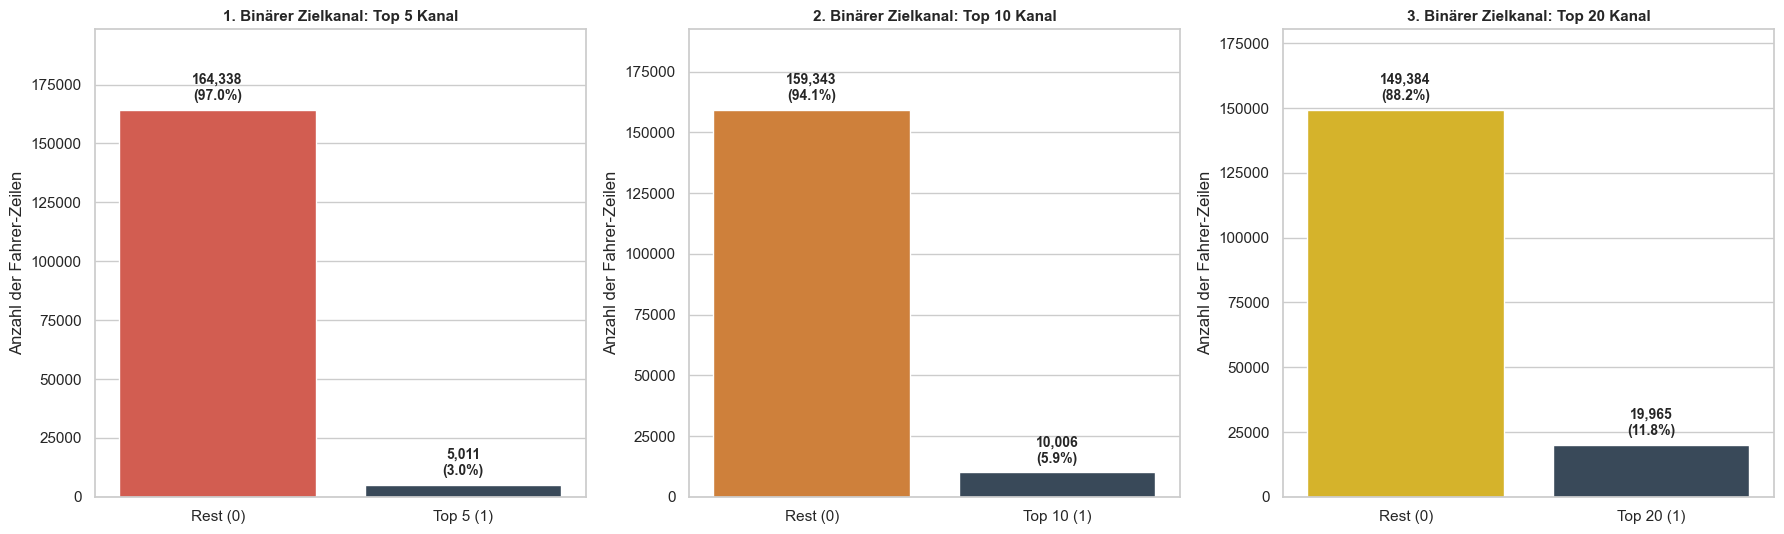

In [52]:
chart_path = '../../data/charts'
os.makedirs(chart_path, exist_ok=True)

# Temporäres DataFrame für die Visualisierung der binären Zielverteilungen
# Jede Spalte repräsentiert einen Frank-&-Hall-Schwellenwertkanal.
df_bin_vis = pd.DataFrame({
    'Top 5 Kanal': y_top5_train.map({1: 'Top 5 (1)', 0: 'Rest (0)'}),
    'Top 10 Kanal': y_top10_train.map({1: 'Top 10 (1)', 0: 'Rest (0)'}),
    'Top 20 Kanal': y_top20_train.map({1: 'Top 20 (1)', 0: 'Rest (0)'})
})

# Plot-Bereich definieren: eine Zeile mit drei Teilplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
sns.set_theme(style="whitegrid")

channels = ['Top 5 Kanal', 'Top 10 Kanal', 'Top 20 Kanal']

color_palettes = [
    ['#34495e', '#e74c3c'],  # Top 5: Rest vs positive Klasse
    ['#34495e', '#e67e22'],  # Top 10: Rest vs positive Klasse
    ['#34495e', '#f1c40f']   # Top 20: Rest vs positive Klasse
]

for idx, channel in enumerate(channels):

    # Sortierung: Restklasse zuerst, positive Klasse danach
    order_labels = [
        label for label in df_bin_vis[channel].unique() if '(0)' in label
    ] + [
        label for label in df_bin_vis[channel].unique() if '(1)' in label
    ]

    # Countplot für den jeweiligen binären Zielkanal
    # hue=channel verhindert die Seaborn-Warnung bei palette.
    sns.countplot(
        data=df_bin_vis,
        x=channel,
        hue=channel,
        ax=axes[idx],
        palette=color_palettes[idx],
        order=order_labels,
        legend=False
    )

    axes[idx].set_title(
        f'{idx + 1}. Binärer Zielkanal: {channel}',
        fontsize=11,
        fontweight='bold'
    )

    axes[idx].set_ylabel('Anzahl der Fahrer-Zeilen')
    axes[idx].set_xlabel('')

    # Absolutwerte und Prozentanteile über den Balken anzeigen
    counts_dict = df_bin_vis[channel].value_counts()
    total_samples = len(df_bin_vis)

    for label_idx, label_name in enumerate(order_labels):
        height = counts_dict[label_name]
        percentage = f'{100 * height / total_samples:.1f}%'

        axes[idx].annotate(
            f"{height:,d}\n({percentage})",
            (label_idx, height),
            ha='center',
            va='bottom',
            fontweight='bold',
            fontsize=10,
            xytext=(0, 5),
            textcoords='offset points'
        )

    # Mehr Platz für Beschriftungen oberhalb der Balken
    axes[idx].set_ylim(0, axes[idx].get_ylim()[1] * 1.15)

plt.tight_layout()

plt.savefig(
    os.path.join(chart_path, '10-01-02_01_binary_channels_distribution.png'),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Erstellung des Basismodells

Bevor ein systematisches Hyperparameter-Tuning durchgeführt wird, wird zunächst ein bewusst einfaches und transparentes 1D-Basismodell etabliert. Dieses dient als methodische Referenz, um die isolierte Vorhersagekraft der einzelnen Features in einem rein pointwise formulierten Klassifikationsansatz zu untersuchen.

Im aktuellen Modellaufbau wird das ordinale Platzierungsproblem nicht als einzelnes Multiklassenmodell formuliert, sondern gemäß Frank und Hall (2001) in drei binäre Schwellenwertprobleme zerlegt. Konkret werden drei separate EBM-Klassifikatoren für die kumulativen Zielkanäle `Top 5`, `Top 10` und `Top 20` trainiert.

### Methodisches Vorgehen im Basismodell

* **Zielstruktur:** Das ursprüngliche Rankingproblem wird über drei binäre Zielkanäle approximiert: `Top 5`, `Top 10` und `Top 20`. Jeder Kanal beantwortet die Frage, ob ein Fahrer die jeweilige Platzierungszone erreicht oder nicht.
* **Klassengewichtung:** Für jeden der drei Kanäle wird ein eigenes `sample_weight`-Array berechnet. Dadurch wird innerhalb jedes binären Modells die starke Unwucht zwischen positiver Spitzenklasse und negativer Restklasse ausgeglichen.
* **Isolierte Haupteffekte:** Im Basismodell werden sämtliche Feature-Interaktionen deaktiviert (`interactions=0`). Jedes Modell lernt somit ausschließlich additive 1D-Effekte der einzelnen Merkmale.
* **Relevanzscore:** Die vorhergesagten Wahrscheinlichkeiten der drei Schwellenwertmodelle werden anschließend addiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Dieser aggregierte Score dient später als kontinuierlicher Ranking-Score für die Sortierung der Fahrer innerhalb einer Etappe.

### Kritische methodische Anmerkung zur Performance-Messung

Da die EBM-Modelle als klassische pointwise Klassifikatoren trainiert werden, erfolgt die erste Modellbewertung auf Klassifikationsebene über den ROC-AUC-Score der einzelnen Schwellenwertkanäle. Dabei wird für jeden Kanal separat geprüft, wie gut das Modell zwischen Fahrern innerhalb und außerhalb der jeweiligen Platzierungszone unterscheiden kann.

Die ROC-AUC-Werte der Kanäle `Top 5`, `Top 10` und `Top 20` dienen somit als globale Proxy-Metriken für die Trennschärfe des Modells. Sie messen jedoch nicht direkt, ob die Fahrer innerhalb einer einzelnen Etappe korrekt relativ zueinander sortiert werden.

Da das eigentliche sportliche Ziel in der etappeninternen Priorisierung der Fahrer liegt, besitzt die globale ROC-AUC nur eine eingeschränkte Aussagekraft für die praktische Rankingqualität. Die finale Bewertung der Modellgüte erfolgt daher später zusätzlich über rankingbasierte Evaluationsmaße wie NDCG@5, NDCG@10, NDCG@20, Winner-Hit-Rates und Spearman-Rangkorrelation.

### Die exakte Konfiguration der EBM-Basismodelle

Für alle drei Schwellenwertkanäle wird dieselbe Basiskonfiguration verwendet:

* `interactions=0`: Deaktiviert alle paarweisen Feature-Interaktionen. Dadurch entstehen reine additive 1D-Modelle.
* `outer_bags=1`: Verzichtet auf umfangreiches Ensembling, um einen schnellen und transparenten Baseline-Wert zu erhalten.
* `validation_size=0.15`: Trennt intern 15 % der Trainingsdaten für Early Stopping ab. Diese interne Validierungsmenge dient ausschließlich der Trainingssteuerung und nicht der externen Hyperparameter-Auswahl.
* `max_rounds=5000`: Legt die maximale Anzahl an Boosting-Iterationen fest.
* `early_stopping_rounds=100`: Beendet das Training automatisch, wenn sich der interne Validierungsfehler über 100 Runden nicht verbessert.
* `early_stopping_tolerance=1e-05`: Definiert die minimale Verbesserung, die als Fortschritt gewertet wird.
* `learning_rate=0.015`: Verwendet eine reduzierte Schrittweite, um die Effektfunktionen stabil zu lernen.
* `random_state=42`: Sichert die Reproduzierbarkeit der Ergebnisse.
* `n_jobs=-1`: Nutzt alle verfügbaren CPU-Kerne, um das Training der drei Modelle effizienter durchzuführen.

Das Basismodell bildet damit eine transparente Ausgangsbasis, gegen die spätere GA²M-Varianten mit Interaktionen und Ensembling verglichen werden können.

In [53]:
start_base = time.time()

print("Initialisiere und berechne sample_weights für multibinäres System...")
# 1. Gewichte strikt basierend auf den jeweiligen binären Kanälen berechnen
weights_top5 = compute_sample_weight(class_weight='balanced', y=y_top5_train)
weights_top10 = compute_sample_weight(class_weight='balanced', y=y_top10_train)
weights_top20 = compute_sample_weight(class_weight='balanced', y=y_top20_train)

# 2. Drei EBM-Basismodelle initialisieren (Pures 1D-Modell, keine Interaktionen)
ebm_params = {
    'interactions': 0,                # Keine Feature-Paare erlauben (1D-Modelle)
    'learning_rate': 0.015,           # Kontrollierte Schrittweite
    'outer_bags': 1,                  # Ein einzelnes Modell pro Kanal für die Baseline
    'validation_size': 0.15,          # 15% interne Validierung NUR für Early Stopping
    'max_rounds': 5000,               # Maximale Iterationen
    'early_stopping_rounds': 100,     # Stop, wenn 100 Runden kein Fortschritt
    'early_stopping_tolerance': 1e-05,
    'random_state': 42,               # Reproduzierbarkeit
    'n_jobs': -1                      # Parallel auf allen Kernen rechnen
}

ebm_base_top5 = ExplainableBoostingClassifier(**ebm_params)
ebm_base_top10 = ExplainableBoostingClassifier(**ebm_params)
ebm_base_top20 = ExplainableBoostingClassifier(**ebm_params)

# 3. Modelle mit den jeweiligen binären Targets und Gewichten trainieren
print("--Trainiere EBM für Top-5-Schwellenwert...")
ebm_base_top5.fit(X_train, y_top5_train, sample_weight=weights_top5)

print("--Trainiere EBM für Top-10-Schwellenwert...")
ebm_base_top10.fit(X_train, y_top10_train, sample_weight=weights_top10)

print("--Trainiere EBM für Top-20-Schwellenwert...")
ebm_base_top20.fit(X_train, y_top20_train, sample_weight=weights_top20)

# 4. Vorhersagewahrscheinlichkeiten für die Validierungsphase (Saison 2023) generieren
probs_top5_base = ebm_base_top5.predict_proba(X_valid)[:, 1]
probs_top10_base = ebm_base_top10.predict_proba(X_valid)[:, 1]
probs_top20_base = ebm_base_top20.predict_proba(X_valid)[:, 1]

# Das Herzstück nach Frank & Hall: Addition der Wahrscheinlichkeiten ergibt den Relevanz-Score
ensemble_score_valid_base = probs_top5_base + probs_top10_base + probs_top20_base

# binäre Validierungstargets für alle 3 Kanäle
y_valid_top5_binary = y_top5_valid.astype(int)
y_valid_top10_binary = y_top10_valid.astype(int)
y_valid_top20_binary = y_top20_valid.astype(int)

# AUROC
auc_top5 = roc_auc_score(y_valid_top5_binary, probs_top5_base)
auc_top10 = roc_auc_score(y_valid_top10_binary, probs_top10_base)
auc_top20 = roc_auc_score(y_valid_top20_binary, probs_top20_base)


# Da die drei Modelle unabhängig trainiert werden, kann es theoretisch passieren,
# dass P(Top5) > P(Top10) oder P(Top10) > P(Top20).
# Diese Kontrolle misst, wie häufig solche Monotonieverletzungen auftreten.
monotonic_violations = np.mean(
    (probs_top5_base > probs_top10_base) |
    (probs_top10_base > probs_top20_base)
)

duration_base = time.time() - start_base
print("==================================================================")
print(" Ergebnisse")
print("==================================================================")
print(f"Baseline ROC-AUC - Top 5 Kanal: {auc_top5:.4f}")
print(f"Baseline ROC-AUC - Top 10 Kanal: {auc_top10:.4f}")
print(f"Baseline ROC-AUC - Top 20 Kanal: {auc_top20:.4f}")
print(f"Monotonieverletzungen der Schwellenwahrscheinlichkeiten: {monotonic_violations * 100:.2f}%")
print("------------------------------------------------------------------")
print(f"Benötigte Rechenzeit für das gesamte Dreifach-Training: {duration_base:.1f} Sekunden")
print("==================================================================")

Initialisiere und berechne sample_weights für multibinäres System...
--Trainiere EBM für Top-5-Schwellenwert...
--Trainiere EBM für Top-10-Schwellenwert...
--Trainiere EBM für Top-20-Schwellenwert...
 Ergebnisse
Baseline ROC-AUC - Top 5 Kanal: 0.7340
Baseline ROC-AUC - Top 10 Kanal: 0.7187
Baseline ROC-AUC - Top 20 Kanal: 0.7065
Monotonieverletzungen der Schwellenwahrscheinlichkeiten: 53.15%
------------------------------------------------------------------
Benötigte Rechenzeit für das gesamte Dreifach-Training: 417.0 Sekunden


### Weitere Metriken und Schwellenwert-Optimierung (Validation Set 2023)

**Hintergrund der Schwellenwert-Anpassung:**  
Nach dem Training der drei binären EBM-Schwellenwertmodelle liegen für jede Fahrer-Zeile der Validierungssaison 2023 drei separate Wahrscheinlichkeiten vor:

$$
P(\text{Top5} \mid x_i), \quad P(\text{Top10} \mid x_i), \quad P(\text{Top20} \mid x_i)
$$

Diese Wahrscheinlichkeiten beschreiben jeweils, wie wahrscheinlich es ist, dass ein Fahrer die entsprechende Platzierungszone erreicht. Für die spätere etappenbasierte Sortierung werden die drei Wahrscheinlichkeiten zu einem kontinuierlichen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Dieser Score liegt theoretisch im Wertebereich von 0 bis 3. Je höher der Score ausfällt, desto stärker wird ein Fahrer vom Modell als Kandidat für vordere Platzierungen eingeschätzt.

Für eine zusätzliche binäre Zwischen-Evaluierung des Top-10-Kanals muss jedoch ein separater Schwellenwert definiert werden. Dieser legt fest, ab welchem aggregierten Relevanzscore ein Fahrer als Top-10-Kandidat klassifiziert wird.

Ein naiver Standard-Schwellenwert von 0,5 ist in diesem Setup nicht sinnvoll, da der verwendete Relevanzscore nicht aus einer einzelnen Wahrscheinlichkeit besteht, sondern aus der Summe dreier binärer Schwellenwertwahrscheinlichkeiten. Zusätzlich wurden die drei Einzelmodelle mit klassengewichteten Verlustfunktionen trainiert, wodurch die seltenen positiven Klassen der Spitzenplatzierungen gezielt stärker berücksichtigt werden. Daher wird der optimale Schwellenwert empirisch auf dem Validierungsset bestimmt.

**Methodisches Vorgehen:**  
Der optimale Schwellenwert wird ausschließlich auf der Validierungssaison 2023 gesucht. Als Zielgröße dient der F1-Score des Top-10-Kanals, da dieser Precision und Recall der seltenen positiven Klasse gemeinsam berücksichtigt. Das Testset der Saisons 2024/2025 bleibt während dieses gesamten Optimierungsschritts vollständig unberührt, wodurch informationelles Data Leakage vermieden wird.

#### ROC-Kurven der drei Schwellenwertkanäle

Vor der Schwellenwert-Optimierung wird zunächst die globale Trennschärfe der drei binären EBM-Kanäle über ROC-Kurven und den jeweiligen AUROC-Wert untersucht. Die ROC-Kurve visualisiert das Verhältnis zwischen Richtig-Positiv-Rate (*True Positive Rate / Sensitivity*) und Falsch-Positiv-Rate (*False Positive Rate*) über alle möglichen Schwellenwerte hinweg.

Da im aktuellen Frank-&-Hall-Setup drei separate binäre Modelle trainiert werden, wird die ROC-AUC nicht als einzelner Multiclass-Wert berechnet, sondern separat für die drei Zielkanäle:

- `Top 5` vs. Rest
- `Top 10` vs. Rest
- `Top 20` vs. Rest

Die Validierungsergebnisse des 1D-Basismodells lauten:

| Zielkanal | ROC-AUC |
|---|---:|
| Top 5 | 0.7340 |
| Top 10 | 0.7187 |
| Top 20 | 0.7065 |

Alle drei Werte liegen deutlich oberhalb eines Zufallsklassifikators mit einer ROC-AUC von 0,50. Das Basismodell besitzt somit bereits ohne Interaktionseffekte eine erkennbare globale Trennschärfe auf pointwise Ebene.

Gleichzeitig ist zu beachten, dass ROC-AUC lediglich bewertet, wie gut das Modell positive und negative Fahrer-Zeilen global voneinander unterscheiden kann. Die Metrik sagt noch nicht aus, ob die Fahrer innerhalb einer einzelnen Etappe korrekt relativ zueinander sortiert werden. Die eigentliche sportliche Modellgüte wird daher später zusätzlich über rankingbasierte Metriken wie NDCG@5, NDCG@10, NDCG@20, Winner-Hit-Rates und Spearman-Rangkorrelation bewertet.

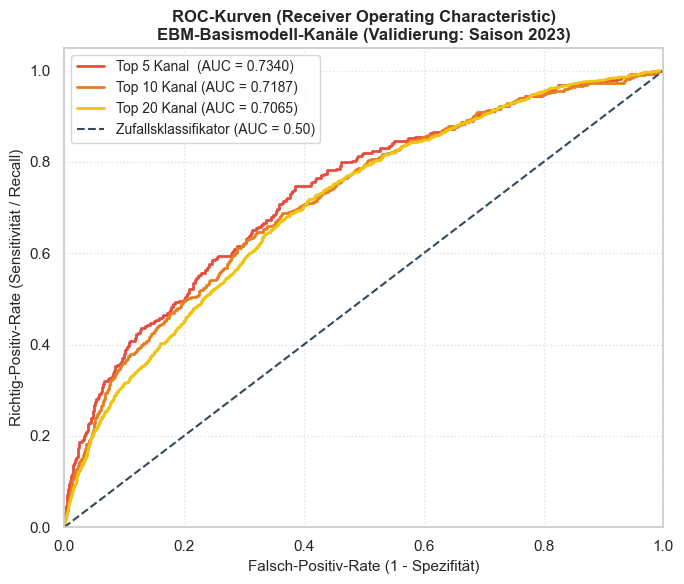

In [12]:
# 1. ROC-Kurven für alle 3 binären Kanäle berechnen –mit den Validierungsdaten von 2023
fpr_5, tpr_5, _ = roc_curve(y_valid_top5_binary, probs_top5_base)
fpr_10, tpr_10, _ = roc_curve(y_valid_top10_binary, probs_top10_base)
fpr_20, tpr_20, _ = roc_curve(y_valid_top20_binary, probs_top20_base)

# 2. Plot erstellen
plt.figure(figsize=(7, 6))

# Die 3 Kurven eintragen
plt.plot(fpr_5, tpr_5, color='#e74c3c', lw=2, label=f'Top 5 Kanal  (AUC = {auc_top5:.4f})')
plt.plot(fpr_10, tpr_10, color='#e67e22', lw=2, label=f'Top 10 Kanal (AUC = {auc_top10:.4f})')
plt.plot(fpr_20, tpr_20, color='#f1c40f', lw=2, label=f'Top 20 Kanal (AUC = {auc_top20:.4f})')

# Die diagonale Zufallslinie
plt.plot([0, 1], [0, 1], color='#34495e', lw=1.5, linestyle='--', label='Zufallsklassifikator (AUC = 0.50)')

# Achsen-Limits und Beschriftungen akademisch formatieren
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Falsch-Positiv-Rate (1 - Spezifität)', fontsize=11)
plt.ylabel('Richtig-Positiv-Rate (Sensitivität / Recall)', fontsize=11)

# Titel an das neue Multibinär-System anpassen
plt.title('ROC-Kurven (Receiver Operating Characteristic)\nEBM-Basismodell-Kanäle (Validierung: Saison 2023)', fontsize=12, fontweight='bold')

plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

# 3. Speichern und anzeigen
plt.tight_layout()
# Der Dateiname dokumentiert nun das Multi-Kanal-System
plt.savefig(os.path.join(chart_path, '10-01-02_02_baseline_multi_roc_curve.png'), dpi=300)
plt.show()

## Interpretation der globalen Modellgüte (AUROC & ROC-Kurven)

Um die Leistung der EBM-Baseline auf pointwise Klassifikationsebene wissenschaftlich einzuordnen, werden die **Receiver Operating Characteristic (ROC)** und der dazugehörige **Area Under the Curve (AUROC)**-Wert für alle drei binären Schwellenwertkanäle betrachtet. Die ROC-Kurve beschreibt das Verhältnis zwischen Richtig-Positiv-Rate (*True Positive Rate / Sensitivity*) und Falsch-Positiv-Rate (*False Positive Rate*) über alle möglichen Entscheidungsschwellen hinweg (vgl. Fawcett, 2006).

### 1. Bedeutung der AUROC-Werte

Der AUROC-Wert misst die globale Trennschärfe eines Klassifikators unabhängig von einem festen Schwellenwert. Mathematisch kann die AUC als Wahrscheinlichkeit interpretiert werden, dass ein zufällig ausgewähltes positives Beispiel vom Modell höher bewertet wird als ein zufällig ausgewähltes negatives Beispiel (vgl. Hanley & McNeil, 1982).

Übertragen auf die drei binären EBM-Kanäle bedeutet dies:

* **Top-5-Kanal:** Wahrscheinlichkeit, dass ein tatsächlicher Top-5-Fahrer höher bewertet wird als ein Fahrer außerhalb der Top 5.
* **Top-10-Kanal:** Wahrscheinlichkeit, dass ein tatsächlicher Top-10-Fahrer höher bewertet wird als ein Fahrer außerhalb der Top 10.
* **Top-20-Kanal:** Wahrscheinlichkeit, dass ein tatsächlicher Top-20-Fahrer höher bewertet wird als ein Fahrer außerhalb der Top 20.

Die Validierungsergebnisse des 1D-Basismodells lauten:

| Zielkanal | AUROC |
|---|---:|
| Top 5 | 0.7340 |
| Top 10 | 0.7187 |
| Top 20 | 0.7065 |

Alle drei Werte liegen deutlich oberhalb eines Zufallsklassifikators mit einer AUROC von 0,50. Werte im Bereich von etwa 0,70 bis 0,80 werden häufig als akzeptable diskriminative Trennschärfe interpretiert (vgl. Hosmer & Lemeshow, 2000). Damit zeigt bereits das rein additive 1D-Basismodell eine solide Fähigkeit, Fahrer der jeweiligen Spitzenzonen global vom restlichen Fahrerfeld zu unterscheiden.

### 2. Interpretation der ROC-Kurven

Die diagonale Referenzlinie von \((0,0)\) bis \((1,1)\) repräsentiert die Leistung eines uninformierten Zufallsklassifikators mit einer AUROC von 0,50. Je stärker sich eine ROC-Kurve nach links oben in Richtung des idealen Klassifikationspunktes \((0,1)\) wölbt, desto besser ist die Trennschärfe des jeweiligen Modells.

Die drei ROC-Kurven zeigen, dass das Basismodell bereits ohne Feature-Interaktionen relevante Signale in den vorhandenen Merkmalen erkennt. Der höchste AUROC-Wert wird im `Top 5`-Kanal erzielt, gefolgt vom `Top 10`- und `Top 20`-Kanal. Dies deutet darauf hin, dass die absolute Spitzengruppe anhand der vorhandenen Fahrer-, Team- und Streckenmerkmale etwas klarer vom restlichen Feld unterscheidbar ist als die breiter gefassten Platzierungszonen.

### 3. Methodische Einordnung im Projektkontext

Trotz der soliden AUROC-Werte ist zu beachten, dass diese Metriken ausschließlich die globale pointwise Trennschärfe bewerten. Sie beantworten also die Frage, ob ein Modell positive und negative Fahrer-Zeilen eines bestimmten Zielkanals über alle Etappen hinweg unterscheiden kann.

Die eigentliche sportliche Zielsetzung besteht jedoch darin, die Fahrer innerhalb einer geschlossenen Etappe (`stage_id`) relativ zueinander korrekt zu sortieren. Aus den AUROC-Werten lässt sich daher nur eingeschränkt ableiten, ob die resultierende Fahrerreihenfolge innerhalb einer einzelnen Etappe qualitativ hochwertig ist.

Aus diesem Grund dienen die AUROC-Werte in dieser Arbeit primär als Proxy-Metriken auf Klassifikationsebene. Die finale Beurteilung der praktischen Modellgüte erfolgt anschließend über rankingbasierte Evaluationsmetriken wie NDCG@5, NDCG@10, NDCG@20, Winner-Hit-Rates und Spearman-Rangkorrelation.

**Der optimale Threshold (F1-Score Maximierung)**


In [54]:

# SCHWELLENWERT-OPTIMIERUNG AUF DEM AGGREGIERTEN EBM-RELEVANZSCORE
# Validation Set: Saison 2023


# Ziel:
# Der aggregierte Score aus den drei binären EBM-Kanälen
#
# score = P(Top20) + P(Top10) + P(Top5)
#
# soll für eine zusätzliche binäre Evaluation in "Top 10" vs. "Nicht Top 10"
# übersetzt werden.
#
# Da dieser Score nicht im Bereich 0 bis 1 liegt, sondern theoretisch zwischen
# 0 und 3, ist ein Standard-Threshold von 0.5 nicht sinnvoll.
# Deshalb wird der beste Threshold auf dem Validierungsset gesucht.

best_thresh = 0.0
best_f1 = 0.0

# Der aggregierte Score liegt theoretisch im Bereich [0, 3].
# Wir testen mögliche Schwellenwerte in kleinen Schritten.
for thresh in np.arange(0.0, 3.01, 0.01):

    # Eine Fahrer-Zeile wird als Top-10-Kandidat klassifiziert,
    # wenn der aggregierte Relevanzscore mindestens den aktuellen Threshold erreicht.
    preds_bin_temp = (ensemble_score_valid_base >= thresh).astype(int)

    # F1-Score für die positive Klasse "Top 10" berechnen.
    # zero_division=0 verhindert Fehler, falls bei einem Threshold keine positiven
    # Vorhersagen entstehen.
    f1_temp = f1_score(
        y_valid_top10_binary,
        preds_bin_temp,
        zero_division=0
    )

    # Besten Threshold speichern
    if f1_temp > best_f1:
        best_f1 = f1_temp
        best_thresh = thresh



# FINALE VALIDIERUNGSVORHERSAGE MIT OPTIMALEM THRESHOLD


y_valid_pred_bin = (
    ensemble_score_valid_base >= best_thresh
).astype(int)



# KLASSISCHE BINÄRE METRIKEN FÜR DEN TOP-10-KANAL


acc_valid = accuracy_score(
    y_valid_top10_binary,
    y_valid_pred_bin
)

prec_valid = precision_score(
    y_valid_top10_binary,
    y_valid_pred_bin,
    zero_division=0
)

rec_valid = recall_score(
    y_valid_top10_binary,
    y_valid_pred_bin,
    zero_division=0
)

f1_valid = f1_score(
    y_valid_top10_binary,
    y_valid_pred_bin,
    zero_division=0
)



# AUSGABE


print("==================================================================")
print(f"OPTIMALER ENSEMBLE-THRESHOLD GEFUNDEN: {best_thresh:.4f}")
print("==================================================================")
print("METRIKEN AUF DEM VALIDIERUNGSSET (SAISON 2023 - TOP-10-KANAL)")
print("------------------------------------------------------------------")
print(f"➔ Classification Accuracy : {acc_valid * 100:.2f}%")
print(f"➔ Precision (Top 10)      : {prec_valid * 100:.2f}%")
print(f"➔ Recall (Top 10)         : {rec_valid * 100:.2f}%")
print(f"➔ F1-Score (Top 10)       : {f1_valid * 100:.2f}%")
print("------------------------------------------------------------------")

print("\nDetaillierter Klassifikationsbericht:")
print(
    classification_report(
        y_valid_top10_binary,
        y_valid_pred_bin,
        target_names=["Nicht Top 10", "Top 10"],
        digits=4
    )
)

print("==================================================================")

OPTIMALER ENSEMBLE-THRESHOLD GEFUNDEN: 2.1100
METRIKEN AUF DEM VALIDIERUNGSSET (SAISON 2023 - TOP-10-KANAL)
------------------------------------------------------------------
➔ Classification Accuracy : 87.28%
➔ Precision (Top 10)      : 21.03%
➔ Recall (Top 10)         : 35.79%
➔ F1-Score (Top 10)       : 26.49%
------------------------------------------------------------------

Detaillierter Klassifikationsbericht:
              precision    recall  f1-score   support

Nicht Top 10     0.9538    0.9080    0.9304      8327
      Top 10     0.2103    0.3579    0.2649       570

    accuracy                         0.8728      8897
   macro avg     0.5821    0.6330    0.5976      8897
weighted avg     0.9062    0.8728    0.8877      8897



# Prüfen ob Bedarf?? 
# nur Top 10 oder alle oder garkeine weil wir sowieso nur auf die Scores schauen
## Interpretation der Schwellenwert-Optimierung & des F1-Scores (Validation Set 2023)

Die Bestimmung des optimalen Schwellenwerts liefert einen tieferen Einblick in das Entscheidungsverhalten des ungetunten 1D-Basismodells auf der Validierungssaison 2023. Da das Modell im aktuellen Ansatz nicht als einzelner Multiklassenklassifikator trainiert wird, sondern aus drei binären EBM-Schwellenwertmodellen besteht, erfolgt die Top-10-Klassifikation nicht über eine einzelne Klassenwahrscheinlichkeit. Stattdessen wird zunächst ein aggregierter Relevanzscore gebildet:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Dieser Score liegt theoretisch im Bereich von 0 bis 3. Je höher der Wert ausfällt, desto konsistenter schätzen die drei Teilmodelle einen Fahrer als Kandidaten für vordere Platzierungsbereiche ein.

### 1. Der optimale Ensemble-Threshold (2.11)

Der auf dem Validierungsset bestimmte optimale Schwellenwert beträgt **2.11**. Dieser Wert ist nicht als klassische Wahrscheinlichkeit zu interpretieren, sondern als Entscheidungsgrenze auf dem aggregierten EBM-Relevanzscore.

Eine Fahrer-Zeile wird somit erst dann als Top-10-Kandidat klassifiziert, wenn die aufsummierten Wahrscheinlichkeiten der drei Schwellenwertmodelle mindestens den Wert **2.11** erreichen. Da der Score aus drei Einzelwahrscheinlichkeiten besteht, deutet dieser vergleichsweise hohe Schwellenwert auf ein konservatives Entscheidungsverhalten hin: Das Modell stuft einen Fahrer nur dann als Top-10-relevant ein, wenn mehrere Teilmodelle gleichzeitig ein starkes Signal für vordere Platzierungen liefern.

Die Schwellenwertsuche erfolgt ausschließlich auf der Validierungssaison 2023. Das Testset der Saisons 2024/2025 bleibt während dieses Optimierungsschritts vollständig unberührt, sodass kein informationelles Data Leakage entsteht.

### 2. F1-Score und binäre Top-10-Metriken

Mit dem optimierten Threshold erreicht das Basismodell auf dem Validierungsset folgende Kennzahlen für den Top-10-Kanal:

| Metrik | Wert |
|---|---:|
| Accuracy | 87.28 % |
| Precision (Top 10) | 21.03 % |
| Recall (Top 10) | 35.79 % |
| F1-Score (Top 10) | 26.49 % |

Der F1-Score von **26.49 %** ergibt sich als harmonisches Mittel aus Precision und Recall. Er beschreibt damit den Kompromiss zwischen zwei gegenläufigen Anforderungen: Einerseits sollen möglichst viele tatsächliche Top-10-Fahrer erkannt werden, andererseits soll die Anzahl der Fehlalarme begrenzt bleiben.

Die Precision von **21.03 %** bedeutet, dass gut jeder fünfte vom Modell als Top-10-Kandidat klassifizierte Fahrer tatsächlich in den Top 10 landet. Der Recall von **35.79 %** zeigt, dass das Modell mehr als ein Drittel aller tatsächlichen Top-10-Platzierungen korrekt als relevant erkennt.

### 3. Einordnung im Kontext unbalancierter Daten

Die positive Klasse ist im Validierungsset stark unterrepräsentiert: Von insgesamt 8.897 Fahrer-Zeilen gehören nur 570 zur Top-10-Klasse, was etwa **6.4 %** entspricht. In einem solchen Setting ist die Accuracy nur eingeschränkt aussagekräftig, da ein Modell bereits durch überwiegend negative Vorhersagen hohe Genauigkeitswerte erzielen könnte.

Die Top-10-spezifischen Kennzahlen Precision, Recall und F1-Score sind daher deutlich informativer. Trotz der niedrigen absoluten Precision zeigt das Modell eine klare Verdichtung relevanter Fahrer: Die Trefferquote unter den vorhergesagten Top-10-Kandidaten liegt deutlich über der natürlichen Basiswahrscheinlichkeit von 6.4 %.

### 4. Methodische Bedeutung für das Rankingproblem

Die Ergebnisse verdeutlichen zugleich die zentrale Grenze des pointwise Klassifikationsansatzes. Das Modell bewertet jede Fahrer-Etappen-Kombination isoliert und weiß während der Klassifikation nicht, dass innerhalb einer Etappe nur eine begrenzte Anzahl an Top-10-Plätzen vergeben werden kann.

Dadurch kann es vorkommen, dass innerhalb einer Etappe mehr als zehn Fahrer einen Score oberhalb des gewählten Schwellenwerts erhalten. Ebenso werden Fahrer, die knapp außerhalb der Top 10 landen, im binären Target vollständig als Fehler behandelt, obwohl das Modell ihre sportliche Stärke möglicherweise plausibel eingeschätzt hat.

### Fazit für die weitere Modellierung

Die Schwellenwert-Optimierung zeigt, dass das Basismodell bereits relevante Strukturen zur Identifikation von Top-10-Fahrern erlernt. Gleichzeitig machen die Ergebnisse deutlich, dass klassische binäre Klassifikationsmetriken nur einen begrenzten Blick auf die eigentliche Zielsetzung der Arbeit erlauben.

Da das sportliche Ziel nicht nur in der globalen Trennung von Top-10- und Nicht-Top-10-Fahrern besteht, sondern in der korrekten Sortierung der Fahrer innerhalb einzelner Etappen, wird die Modellgüte anschließend zusätzlich über rankingbasierte Metriken wie NDCG@5, NDCG@10, NDCG@20, Winner-Hit-Rates und Spearman-Rangkorrelation bewertet.

**Classification Report**

In [55]:
print("==================================================================")
print(f" FINALER KLASSIFIKATIONSBERICHT (VALIDIERUNG SAISON 2023)")
print("==================================================================")
print(f"Optimierter Ensemble-Threshold: {best_thresh:.2f}\n")

# Evaluierung der berechneten Ensemble-Prognosen gegen das binäre 2023er-Target
print(classification_report(
    y_true=y_valid_top10_binary,
    y_pred=y_valid_pred_bin,
    target_names=['Hauptfeld/Top20 (Klasse 0)', 'Top 10 Zielsprung (Klasse 1)'],
    digits=4
))
print("==================================================================")

 FINALER KLASSIFIKATIONSBERICHT (VALIDIERUNG SAISON 2023)
Optimierter Ensemble-Threshold: 2.11

                              precision    recall  f1-score   support

  Hauptfeld/Top20 (Klasse 0)     0.9538    0.9080    0.9304      8327
Top 10 Zielsprung (Klasse 1)     0.2103    0.3579    0.2649       570

                    accuracy                         0.8728      8897
                   macro avg     0.5821    0.6330    0.5976      8897
                weighted avg     0.9062    0.8728    0.8877      8897



## Interpretation des Klassifikationsberichts (EBM-Basismodell – Validierung 2023)

Der finale Klassifikationsbericht betrachtet die Leistung des ungetunten 1D-Basismodells nach Anwendung des optimierten Ensemble-Thresholds von **2.11** auf dem Validierungsset der Saison 2023. Bewertet wird hierbei eine binäre Zwischenaufgabe: Das Modell soll Fahrer-Zeilen in **Top 10** und **Nicht Top 10** einteilen.

Da die positive Klasse `Top 10` mit nur 570 von 8.897 Beobachtungen stark unterrepräsentiert ist, sollte die Interpretation nicht primär über die Accuracy erfolgen. Entscheidend sind vor allem Precision, Recall und F1-Score der Minderheitsklasse.

### 1. Klasse 0: Nicht Top 10 (Majoritätsklasse)

* **Precision (95,38 %):** Wird ein Fahrer vom Modell als `Nicht Top 10` klassifiziert, ist diese Vorhersage in den meisten Fällen korrekt. Das Modell besitzt somit eine hohe Zuverlässigkeit bei der Identifikation von Fahrern außerhalb der vordersten Platzierungszone.

* **Recall (90,80 %):** Von allen tatsächlich nicht in den Top 10 platzierten Fahrern erkennt das Modell rund 91 % korrekt. Die verbleibenden Fälle stellen False Positives dar, also Fahrer, die vom Modell als Top-10-Kandidaten eingestuft werden, obwohl sie real außerhalb der Top 10 landen.

* **F1-Score (93,04 %):** Die hohe F1-Leistung dieser Klasse ist vor allem durch die starke Dominanz der Nicht-Top-10-Beobachtungen im Datensatz begünstigt. Sie zeigt, dass das Modell das breite Fahrerfeld insgesamt gut von der sportlichen Spitze abgrenzen kann.

### 2. Klasse 1: Top 10 (Minderheitsklasse)

* **Precision (21,03 %):** Von allen Fahrern, die das Modell als Top-10-Kandidaten klassifiziert, erreichen **21,03 %** tatsächlich die Top 10. Isoliert betrachtet wirkt dieser Wert niedrig, muss jedoch vor dem Hintergrund der starken Klassenunwucht interpretiert werden: Die natürliche Basisrate der Top-10-Klasse beträgt nur etwa **6,4 %**. Das Modell erhöht die Trefferdichte unter den ausgewählten Kandidaten somit deutlich gegenüber einer zufälligen Auswahl aus dem gesamten Fahrerfeld.

* **Recall (35,79 %):** Das Basismodell identifiziert **35,79 %** aller tatsächlichen Top-10-Platzierungen korrekt. Damit erkennt das rein additive 1D-Modell bereits mehr als ein Drittel der relevanten Spitzenplatzierungen, obwohl es noch keine Feature-Interaktionen berücksichtigt.

* **F1-Score (26,49 %):** Der F1-Score kombiniert Precision und Recall zu einer gemeinsamen Kennzahl. Der Wert von **26,49 %** zeigt, dass das Modell bereits relevante Muster zur Identifikation von Top-10-Fahrern erlernt hat, gleichzeitig aber noch Verbesserungspotenzial bei der Selektivität besitzt. Insbesondere die vergleichsweise niedrige Precision deutet darauf hin, dass weiterhin zahlreiche Fahrer fälschlicherweise als Top-10-Kandidaten eingestuft werden.

### 3. Globale Kennzahlen

* **Accuracy (87,28 %):** Die Gesamtgenauigkeit erscheint hoch, ist aufgrund der starken Klassenunwucht jedoch nur eingeschränkt aussagekräftig. Da rund 93,6 % aller Beobachtungen nicht zur Top-10-Klasse gehören, kann ein Modell bereits durch überwiegend negative Vorhersagen hohe Accuracy-Werte erzielen.

* **Macro Average (F1 = 59,76 %):** Der Macro Average behandelt beide Klassen gleichgewichtet. Der Wert zeigt, dass zwischen der Majoritätsklasse `Nicht Top 10` und der Minderheitsklasse `Top 10` weiterhin ein deutlicher Leistungsunterschied besteht.

* **Weighted Average (F1 = 88,77 %):** Der gewichtete Durchschnitt fällt deutlich höher aus, weil er stark von der dominierenden Klasse `Nicht Top 10` beeinflusst wird. Für die eigentliche sportliche Zielsetzung ist dieser Wert daher nur begrenzt aussagekräftig.

### Fazit für die weitere Modellierung

Die Ergebnisse zeigen, dass das EBM-Basismodell bereits eine sinnvolle globale Trennung zwischen Top-10-Fahrern und dem restlichen Fahrerfeld erlernt. Besonders positiv ist, dass die Trefferquote unter den vorhergesagten Top-10-Kandidaten deutlich über der natürlichen Basisrate liegt und das Modell mehr als ein Drittel der tatsächlichen Top-10-Platzierungen erkennt.

Die zentrale Schwachstelle bleibt jedoch die vergleichsweise niedrige Precision der Top-10-Klasse. Das Modell produziert weiterhin eine relevante Anzahl an Fehlalarmen, also Fahrer-Zeilen, die als Top-10-Kandidaten klassifiziert werden, real aber außerhalb der Top 10 landen.

Eine mögliche Ursache liegt in der bewusst einfachen Architektur des Basismodells. Da alle drei EBM-Kanäle ausschließlich additive Einzeleffekte lernen (`interactions=0`), kann das Modell noch keine komplexen Wechselwirkungen zwischen Fahrer-, Strecken-, Team- und Renncharakteristika berücksichtigen.

Das anschließende Hyperparameter-Tuning verfolgt daher das Ziel, durch paarweise Feature-Interaktionen (GA²M) und stärkeres Ensembling zusätzliche Strukturinformationen nutzbar zu machen. Dadurch soll insbesondere die Selektivität der Vorhersagen verbessert werden, ohne die Fähigkeit zur Identifikation tatsächlicher Top-10-Fahrer wesentlich einzuschränken.

Gleichzeitig bleibt zu beachten, dass dieser Klassifikationsbericht weiterhin nur eine pointwise Zwischenbewertung darstellt. Die eigentliche sportliche Zielsetzung besteht in der korrekten Sortierung der Fahrer innerhalb einzelner Etappen. Deshalb wird die finale Modellgüte zusätzlich über etappenbasierte Rankingmetriken wie NDCG, Winner-Hit-Rates und Spearman-Rangkorrelation bewertet.

**Confusion Matrix**

In [56]:
# 1. Harte binäre Vorhersagen (0 oder 1) für jeden Kanal separat berechnen (Standard-Threshold 0.5)
y_pred_top5_base = (probs_top5_base >= 0.5).astype(int)
y_pred_top10_base = (probs_top10_base >= 0.5).astype(int)
y_pred_top20_base = (probs_top20_base >= 0.5).astype(int)

# 2. Die drei separaten Konfusionsmatrizen berechnen
cm_5 = confusion_matrix(y_valid_top5_binary, y_pred_top5_base)
cm_10 = confusion_matrix(y_valid_top10_binary, y_pred_top10_base)
cm_20 = confusion_matrix(y_valid_top20_binary, y_pred_top20_base)

print("==================================================================")
print(" Konfusion Matritze auf Basis der Validierungsdaten von 2023")
print("==================================================================")

# --- KANAL 1: TOP 5 ---
print("[1. KANAL: TOP 5 SCHWELLENWERT]")
print(f"Tatsächlich Rest (0):   TN: {cm_5[0, 0]:<6,d} | FP (Fehlalarm): {cm_5[0, 1]:,d}")
print(f"Tatsächlich Top 5 (1):  FN: {cm_5[1, 0]:<6,d} | TP (Getroffen): {cm_5[1, 1]:,d}")
print("------------------------------------------------------------------")

# --- KANAL 2: TOP 10 ---
print("[2. KANAL: TOP 10 SCHWELLENWERT]")
print(f"Tatsächlich Rest (0):   TN: {cm_10[0, 0]:<6,d} | FP (Fehlalarm): {cm_10[0, 1]:,d}")
print(f"Tatsächlich Top 10 (1): FN: {cm_10[1, 0]:<6,d} | TP (Getroffen): {cm_10[1, 1]:,d}")
print("------------------------------------------------------------------")

# --- KANAL 3: TOP 20 ---
print("[3. KANAL: TOP 20 SCHWELLENWERT]")
print(f"Tatsächlich Rest (0):   TN: {cm_20[0, 0]:<6,d} | FP (Fehlalarm): {cm_20[0, 1]:,d}")
print(f"Tatsächlich Top 20 (1): FN: {cm_20[1, 0]:<6,d} | TP (Getroffen): {cm_20[1, 1]:,d}")
print("==================================================================")

 Konfusion Matritze auf Basis der Validierungsdaten von 2023
[1. KANAL: TOP 5 SCHWELLENWERT]
Tatsächlich Rest (0):   TN: 6,358  | FP (Fehlalarm): 2,255
Tatsächlich Top 5 (1):  FN: 115    | TP (Getroffen): 169
------------------------------------------------------------------
[2. KANAL: TOP 10 SCHWELLENWERT]
Tatsächlich Rest (0):   TN: 5,975  | FP (Fehlalarm): 2,352
Tatsächlich Top 10 (1): FN: 230    | TP (Getroffen): 340
------------------------------------------------------------------
[3. KANAL: TOP 20 SCHWELLENWERT]
Tatsächlich Rest (0):   TN: 5,424  | FP (Fehlalarm): 2,335
Tatsächlich Top 20 (1): FN: 471    | TP (Getroffen): 667


## Interpretation der Konfusionsmatrizen der drei EBM-Schwellenwertkanäle  
*(EBM-Basismodell – Validierung 2023)*

Die folgenden Konfusionsmatrizen betrachten nicht den finalen Ensemble-Threshold von 2.11, sondern die drei einzelnen binären EBM-Schwellenwertkanäle des Frank-&-Hall-Ansatzes separat. Jeder Kanal beantwortet eine eigene Klassifikationsfrage:

- `Top 5`: Erreicht ein Fahrer die Top 5 oder nicht?
- `Top 10`: Erreicht ein Fahrer die Top 10 oder nicht?
- `Top 20`: Erreicht ein Fahrer die Top 20 oder nicht?

Damit lässt sich analysieren, wie sich das Basismodell auf den einzelnen Relevanzstufen verhält, bevor die drei Wahrscheinlichkeiten zu einem gemeinsamen Ranking-Score aggregiert werden.

### 1. Top-5-Kanal

Im `Top 5`-Kanal erkennt das Modell **169 tatsächliche Top-5-Fahrer korrekt** als positive Fälle. Gleichzeitig werden **115 echte Top-5-Platzierungen übersehen**. Daraus ergibt sich ein vergleichsweise hoher Recall: Das Modell findet also einen relevanten Teil der tatsächlichen Spitzenfahrer.

Die größte Schwäche liegt jedoch in den **2.255 False Positives**. Das Modell stuft viele Fahrer als potenzielle Top-5-Kandidaten ein, die diese Platzierung real nicht erreichen. Dies zeigt, dass der Kanal zwar sensitiv reagiert, aber noch wenig selektiv ist. Für eine extrem kleine Zielklasse wie Top 5 ist dieses Verhalten methodisch erwartbar: Das Modell versucht, seltene Spitzenleistungen zu erkennen, erzeugt dadurch jedoch eine breite Kandidatenmenge.

### 2. Top-10-Kanal

Im `Top 10`-Kanal werden **340 tatsächliche Top-10-Fahrer korrekt erkannt**, während **230 Top-10-Fahrer übersehen** werden. Damit erkennt das Modell einen substanziellen Anteil der relevanten Fahrer.

Gleichzeitig entstehen **2.352 False Positives**. Auch hier zeigt sich, dass das Basismodell noch zu viele Fahrer als relevant einstuft. Der Top-10-Kanal ist damit zwar besser geeignet als der Top-5-Kanal, um eine größere Favoritengruppe zu identifizieren, bleibt aber auf Klassifikationsebene noch relativ unspezifisch.

Dieses Verhalten erklärt, weshalb später ein optimierter Ensemble-Threshold auf dem aggregierten Score benötigt wird. Erst durch die Kombination der drei Kanäle und eine Validierungs-basierte Schwellenwertsuche wird aus den Einzelwahrscheinlichkeiten eine kontrolliertere Top-10-Entscheidung abgeleitet.

### 3. Top-20-Kanal

Der `Top 20`-Kanal weist mit **667 True Positives** die höchste absolute Anzahl korrekt erkannter positiver Fälle auf. Dies ist erwartbar, da die Top-20-Klasse größer ist als die Top-5- und Top-10-Klasse.

Gleichzeitig werden **471 tatsächliche Top-20-Fahrer nicht erkannt** und **2.335 Fahrer fälschlicherweise als Top-20-Kandidaten klassifiziert**. Auch hier zeigt sich das typische Muster des Basismodells: Es erkennt relevante Leistungsstrukturen, erzeugt aber eine relativ breite Menge potenzieller Kandidaten.

Im Vergleich zu den engeren Zielkanälen ist der Top-20-Kanal sportlich weniger streng, aber für den späteren Ranking-Score dennoch wichtig. Eine hohe Top-20-Wahrscheinlichkeit kann darauf hinweisen, dass ein Fahrer grundsätzlich zur erweiterten relevanten Gruppe gehört, auch wenn er nicht zwingend als Top-5- oder Top-10-Kandidat einzustufen ist.

### 4. Übergreifende Einordnung

Über alle drei Kanäle hinweg zeigt sich ein konsistentes Muster:

- Das Modell erkennt bereits relevante Fahrergruppen.
- Die Recall-Werte sind für ein einfaches 1D-Basismodell beachtlich.
- Die Zahl der False Positives ist jedoch in allen Kanälen hoch.
- Die Einzelkanäle sind daher allein noch keine ausreichend selektiven Entscheidungsmodelle.

Dieses Verhalten passt zur Rolle des Basismodells: Es soll zunächst die isolierte Vorhersagekraft der Features sichtbar machen, nicht bereits die finale Rankingqualität maximieren. Da alle drei Modelle rein additive 1D-Effekte lernen (`interactions=0`), können sie komplexe Zusammenhänge zwischen Fahrerprofil, Etappencharakteristik, Teamstärke und Rennsituation noch nicht abbilden.

### 5. Bedeutung für den aggregierten Ranking-Score

Die hohen False-Positive-Zahlen der Einzelkanäle zeigen, warum die drei Wahrscheinlichkeiten nicht isoliert interpretiert werden sollten. Stattdessen werden sie zu einem gemeinsamen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Ein Fahrer erhält dadurch nur dann einen sehr hohen Score, wenn mehrere Schwellenwertmodelle gleichzeitig ein starkes Signal liefern. Genau diese Aggregation reduziert die Abhängigkeit von einem einzelnen, potenziell fehleranfälligen Kanal und bildet die Grundlage für das spätere etappenweise Ranking.

### Fazit für das Hyperparameter-Tuning

Die Konfusionsmatrizen verdeutlichen, dass das EBM-Basismodell bereits relevante Leistungsmuster erkennt, jedoch noch zu breit selektiert. Die zentrale Schwäche liegt in der hohen Zahl an False Positives über alle drei Schwellenwertkanäle hinweg.

Das anschließende Hyperparameter-Tuning verfolgt daher das Ziel, durch paarweise Feature-Interaktionen (GA²M) und stärkeres Ensembling die Selektivität der Modelle zu erhöhen. Insbesondere soll das Modell lernen, Favoriten stärker kontextabhängig zu bewerten, etwa in Abhängigkeit von Streckenprofil, Fahrerbiometrie, historischer Form und Teamstärke. Dadurch soll die Zahl der Fehlalarme reduziert und die spätere Rankingqualität innerhalb einzelner Etappen verbessert werden.

## Interpretation der globalen Feature-Wichtigkeit (EBM-Basismodell)

Mit dem Aufruf von `explain_global()` betrachten wir die globale Feature-Wichtigkeit der drei EBM-Basismodelle. Da das Rankingproblem gemäß Frank und Hall (2001) in drei binäre Schwellenwertkanäle zerlegt wurde, wird die Feature-Wichtigkeit nicht für ein einzelnes Multiklassenmodell, sondern separat für die Kanäle `Top 5`, `Top 10` und `Top 20` interpretiert.

Der *Mean Absolute Score (Weighted)* beschreibt, wie stark ein Merkmal die internen Modell-Scores des jeweiligen binären EBM-Kanals im Durchschnitt beeinflusst. Je höher dieser Wert ausfällt, desto stärker trägt das Feature zur Unterscheidung zwischen positiver Klasse und Restklasse bei. Wichtig ist dabei: Die globale Feature-Wichtigkeit quantifiziert nur die Stärke des Einflusses, nicht dessen Richtung. Ob ein hoher oder niedriger Feature-Wert die Wahrscheinlichkeit erhöht oder senkt, muss anschließend über die jeweiligen Effektkurven analysiert werden.

### 1. Dominanz historischer Leistungsindikatoren

Über alle drei Schwellenwertkanäle hinweg dominieren historische Leistungsmerkmale die Modellentscheidungen. Besonders deutlich ist dies bei:

- `lag_rider_rank_season`
- `lag_rider_points_season`

Der historische Saisonrang (`lag_rider_rank_season`) ist in allen drei Modellen das mit Abstand wichtigste Feature. Dies zeigt, dass die vergangene Leistungsstärke eines Fahrers den zentralen Ausgangspunkt für die Prognose zukünftiger Spitzenplatzierungen bildet.

Auch die historischen Saisonpunkte (`lag_rider_points_season`) besitzen in allen Kanälen eine sehr hohe Bedeutung. Damit bestätigen die Feature-Wichtigkeiten, dass das Modell stark auf vergangene sportliche Leistungsindikatoren zurückgreift, um Fahrer für Top-5-, Top-10- oder Top-20-Platzierungen zu priorisieren.

### 2. Kanalübergreifende Stabilität der wichtigsten Merkmale

Auffällig ist, dass die Rangfolge der wichtigsten Features über die drei Kanäle hinweg relativ stabil bleibt. Neben den historischen Fahrerindikatoren gehören insbesondere folgende Merkmale wiederholt zur Spitzengruppe:

- `lag_race_competitiveness_median`
- `rider_bmi`
- `age_at_race`
- `stage_nr`
- `lag_team_power_index`

Diese Stabilität deutet darauf hin, dass das Basismodell über alle Platzierungsschwellen hinweg ähnliche Grundmuster nutzt. Fahrerhistorie, Wettbewerbsniveau früherer Rennen, körperliche Merkmale, Alter und Teamstärke bilden somit das zentrale Fundament der pointwise Prognose.

### 3. Unterschiede zwischen Top-5-, Top-10- und Top-20-Kanal

Trotz der ähnlichen Grundstruktur zeigen sich leichte Unterschiede zwischen den Kanälen:

- Im `Top 5`-Kanal spielen historische Leistungsindikatoren besonders stark zusammen mit `lag_race_competitiveness_median`, `rider_bmi` und `age_at_race`.
- Im `Top 10`-Kanal dominiert `lag_rider_rank_season` besonders deutlich, während `lag_rider_points_season`, `rider_bmi` und `lag_race_competitiveness_median` ebenfalls hohe Beiträge liefern.
- Im `Top 20`-Kanal bleibt `lag_rider_rank_season` ebenfalls klar führend, während die übrigen Merkmale etwas breiter verteilt wirken.

Dies ist sportlich plausibel: Je enger die Zielzone definiert ist, desto stärker muss das Modell zwischen absoluter Spitze und erweitertem Favoritenkreis unterscheiden. Der Top-20-Kanal bildet hingegen eine breitere Relevanzgruppe ab und ist daher etwas weniger exklusiv.

### 4. Bedeutung von Fahrercharakteristika

Der `rider_bmi` gehört in allen drei Kanälen zu den wichtigsten Merkmalen. Dies legt nahe, dass körperliche Fahrercharakteristika einen konsistenten Beitrag zur Vorhersage leisten.

Da das Basismodell jedoch ausschließlich additive Haupteffekte lernt (`interactions=0`), wird der BMI zunächst nur als globaler Durchschnittseffekt über alle Etappen hinweg modelliert. Eine differenzierte Interpretation ist daher nur eingeschränkt möglich. Sportlich ist zu erwarten, dass die Bedeutung des BMI stark vom Etappenprofil abhängt, beispielsweise von Höhenmetern, Steigungscharakteristik oder Schlussprofil. Genau solche kontextabhängigen Effekte kann das aktuelle Basismodell noch nicht explizit erfassen.

### 5. Teamstärke, Rennstruktur und Etappenkontext

Mit `lag_team_power_index` und `stage_nr` erscheinen auch Team- und Rennstrukturmerkmale im mittleren Wichtigkeitsbereich. Dies deutet darauf hin, dass nicht nur individuelle Fahrerqualität, sondern auch strukturelle Rennbedingungen zur Prognose beitragen.

Die Etappennummer (`stage_nr`) kann beispielsweise indirekt Erschöpfung, Rennverlauf oder strategische Unterschiede innerhalb einer Rundfahrt abbilden. Die historische Teamstärke (`lag_team_power_index`) kann wiederum Hinweise darauf liefern, ob ein Fahrer durch ein leistungsfähiges Team unterstützt wird.

### 6. Topografie und Wetterbedingungen

Topografische Merkmale wie `vertical_meters` und `gradient_final_km` erreichen im Basismodell nur mittlere bis geringe globale Wichtigkeitswerte. Wetter- und Distanzvariablen wie `weather_temp_mean`, `weather_temp_trend`, `wind_stability_index`, `weather_humidity_mean`, `weather_precipitation_mean` und `distance` liegen über alle Kanäle hinweg am unteren Ende der Wichtigkeitsskala.

Dies bedeutet nicht, dass Topografie oder Wetter sportlich irrelevant sind. Vielmehr zeigt es, dass diese Variablen im rein additiven 1D-Basismodell nur begrenzte isolierte Haupteffekte besitzen. Ihre eigentliche Vorhersagekraft könnte sich erst in Kombination mit anderen Merkmalen entfalten, etwa:

- `rider_bmi × vertical_meters`
- `rider_bmi × gradient_final_km`
- `lag_rider_points_season × vertical_meters`
- `lag_team_power_index × stage_nr`
- `weather_temp_mean × rider_bmi`

### Fazit für das Hyperparameter-Tuning

Die globale Feature-Wichtigkeit bestätigt, dass das EBM-Basismodell bereits plausible und sportlich nachvollziehbare Strukturen lernt. Historische Fahrerleistung, Wettbewerbsniveau, Fahrercharakteristika und Teamstärke bilden die wichtigsten Grundlagen der Prognose.

Gleichzeitig zeigt die Analyse eine zentrale Grenze des 1D-Basismodells: Kontextabhängige Effekte zwischen Fahrerprofil, Streckencharakteristik und Rennsituation können ohne Interaktionen nicht explizit modelliert werden. Die vergleichsweise niedrige globale Wichtigkeit topografischer und meteorologischer Variablen liefert daher eine plausible Motivation für das anschließende Hyperparameter-Tuning mit GA²M-Interaktionen.

Ziel des nächsten Modellierungsschritts ist es, durch das Zulassen paarweiser Feature-Wechselwirkungen zusätzliche sportliche Strukturinformationen nutzbar zu machen und insbesondere die Selektivität der Top-Platzierungsprognosen zu verbessern.

In [27]:
global_top5 = ebm_base_top5.explain_global(name="EBM Top 5 Kanal")
global_top10 = ebm_base_top10.explain_global(name="EBM Top 10 Kanal")
global_top20 = ebm_base_top20.explain_global(name="EBM Top 20 Kanal")


show(global_top5)
show(global_top10)
show(global_top20)

<!-- http://127.0.0.1:7001/3070562357888/ -->

<!-- http://127.0.0.1:7001/3070562357216/ -->

<!-- http://127.0.0.1:7001/3070559876352/ -->

# Automatisiertes Hyperparameter-Tuning  
## Grid Search im multibinären Frank-&-Hall-EBM-System

Nach der Analyse des Basismodells erfolgt nun ein systematisches Hyperparameter-Tuning der Explainable Boosting Machines. Ziel ist es, die Generalisierungsfähigkeit der drei binären Schwellenwertmodelle zu verbessern und zusätzliche, kontextabhängige Zusammenhänge zwischen den Merkmalen nutzbar zu machen.

Im Gegensatz zur Baseline werden nun kontrolliert paarweise Feature-Interaktionen zugelassen. Dadurch wird das rein additive 1D-EBM zu einem Generalized Additive Model with Interactions (GA²M) erweitert. Das Modell kann somit nicht nur isolierte Haupteffekte einzelner Features lernen, sondern auch Wechselwirkungen zwischen Fahrer-, Strecken-, Team- und Rennmerkmalen berücksichtigen.

## Strategie der Tuning-Pipeline

### Fokus auf die ordinale Zerlegung in binäre Schwellenwertkanäle

Das Hyperparameter-Tuning erfolgt nicht auf einem einzelnen vierstufigen Multiklassenmodell, sondern auf dem zuvor eingeführten Frank-&-Hall-Ansatz zur ordinalen Klassifikation. Das ursprüngliche Rankingproblem wird dabei über drei kumulative binäre Zielkanäle abgebildet:

- `Top 5` vs. Rest
- `Top 10` vs. Rest
- `Top 20` vs. Rest

Für jede Hyperparameter-Kombination werden somit drei separate EBM-Klassifikatoren trainiert. Jeder dieser Klassifikatoren lernt die Wahrscheinlichkeit, dass ein Fahrer die jeweilige Platzierungsschwelle erreicht.

Die drei vorhergesagten Wahrscheinlichkeiten werden anschließend zu einem gemeinsamen kontinuierlichen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Dieser aggregierte Score dient als Grundlage für die spätere Sortierung der Fahrer innerhalb einzelner Etappen.

### Berücksichtigung der Klassengewichte

Analog zum Basismodell wird auch während des gesamten Suchlaufs für jeden binären Zielkanal ein eigenes `sample_weight`-Array berechnet. Dadurch wird die starke Unwucht zwischen positiver Spitzenklasse und negativer Restklasse kanalweise ausgeglichen.

Die Gewichtung erfolgt somit nicht global über vier gemeinsame Relevanzklassen, sondern separat für die drei binären Schwellenwertprobleme. Dadurch erhalten seltene positive Beobachtungen, beispielsweise tatsächliche Top-5-Platzierungen, innerhalb ihres jeweiligen Kanals ein höheres Gewicht in der Verlustfunktion.

## Zu optimierende Hyperparameter

### 1. `interactions` – Anzahl paarweiser Interaktionseffekte

**Funktion:**  
Der Parameter bestimmt, wie viele automatische Feature-Interaktionen das Modell zusätzlich zu den eindimensionalen Haupteffekten lernen darf.

**Bedeutung für das Projekt:**  
Interaktionen ermöglichen es dem Modell, Zusammenhänge zu erfassen, die durch isolierte Feature-Betrachtungen nicht sichtbar werden. Beispielsweise kann die Bedeutung des `rider_bmi` stark vom Höhenprofil einer Etappe abhängen. Ebenso können historische Leistungsindikatoren je nach Streckencharakteristik unterschiedlich relevant sein.

Da die Analyse des Basismodells gezeigt hat, dass topografische und meteorologische Variablen isoliert nur begrenzte Wichtigkeit besitzen, ist das Zulassen von Interaktionen ein zentraler nächster Modellierungsschritt.

### 2. `outer_bags` – Ensemble-Größe

**Funktion:**  
Der Parameter bestimmt, wie viele unabhängige EBM-Modelle auf leicht unterschiedlichen Stichproben trainiert und anschließend gemittelt werden.

**Bedeutung für das Projekt:**  
Eine größere Anzahl an Bags kann die Stabilität der Vorhersagen erhöhen und die Varianz des Modells reduzieren. Dies ist besonders relevant, da Radsportergebnisse durch Stürze, Defekte, Ausreißergruppen und taktische Rennsituationen stark verrauscht sein können.

### 3. `learning_rate` – Schrittweite des Boosting-Prozesses

**Funktion:**  
Die Lernrate steuert, wie stark die Effektfunktionen pro Boosting-Schritt angepasst werden.

**Bedeutung für das Projekt:**  
Eine kleinere Lernrate führt zu vorsichtigerem Lernen und kann stabilere Effektkurven erzeugen, benötigt jedoch häufig mehr Trainingszeit. Eine höhere Lernrate kann schneller lernen, erhöht aber potenziell das Risiko, zufällige Muster stärker aufzugreifen. Das Tuning sucht daher einen geeigneten Kompromiss zwischen Lernstabilität und Modellleistung.

### 4. Optional: `max_bins` – Auflösung numerischer Variablen

Falls `max_bins` im Suchraum enthalten ist, bestimmt dieser Parameter, in wie viele diskrete Intervalle numerische Variablen vor dem Lernen der Effektfunktionen unterteilt werden.

Größere Werte ermöglichen eine feinere Abbildung nichtlinearer Zusammenhänge, erhöhen jedoch gleichzeitig die Modellkomplexität. Falls `max_bins` im konkreten Code nicht variiert wird, bleibt dieser Parameter auf dem Standardwert der EBM-Implementierung und wird nicht als aktiver Tuningparameter interpretiert.

## Zusammenfassung der Tuning-Strategie

* Das ordinale Rankingproblem wird weiterhin über drei binäre Schwellenwertmodelle (`Top 5`, `Top 10`, `Top 20`) abgebildet.
* Für jede Hyperparameter-Kombination werden drei EBM-Modelle trainiert.
* Die Klassengewichtung erfolgt kanalweise über separate `sample_weight`-Arrays.
* Die drei vorhergesagten Wahrscheinlichkeiten werden zu einem gemeinsamen Relevanzscore aggregiert.
* Die Modellauswahl erfolgt ausschließlich anhand der Validierungssaison 2023.
* Das Testset der Saisons 2024/2025 bleibt während des gesamten Tuningprozesses vollständig unberührt.

## Schutz vor Data Leakage

Die Saison 2023 dient ausschließlich als externe Validierungsperiode für Hyperparameter-Tuning und Modellauswahl. Alle Hyperparameter-Entscheidungen werden ausschließlich anhand dieser Validierungsdaten getroffen.

Das finale EBM-Setup wird erst nach Abschluss der Grid Search ausgewählt. Die nachfolgenden Testsaisons 2024 und 2025 bleiben während des gesamten Entwicklungs- und Tuningprozesses unangetastet und werden ausschließlich für die abschließende Out-of-Sample-Evaluation verwendet.

Dadurch wird sichergestellt, dass die finale Testperformance eine realistische Einschätzung der Generalisierungsfähigkeit des Modells auf zukünftige, bislang ungesehene Rennen darstellt.

In [28]:
model_path = "../../data/models"
os.makedirs(model_path, exist_ok=True)

# Definition des Suchraums für die 3 parallelen EBMs
grid_parameters = {
    'interactions': [5, 12],             # Anzahl der 2D-Wechselwirkungen (GA²M)
    'learning_rate': [0.01, 0.02],        # Schrittweite / Lernrate
    'outer_bags': [4, 8],                 # Ensembling zur Varianzreduktion
    'max_bins': [256]                     # Granularität der numerischen Splines
}

keys, values = zip(*grid_parameters.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

tuning_results = []
best_model_tracker = {'auc_top10': 0.0, 'models': None, 'config': None}

# Alle drei binären Validierungstargets (Saison 2023) vorbereiten
y_valid_top5_binary = y_top5_valid.astype(int)
y_valid_top10_binary = y_top10_valid.astype(int)
y_valid_top20_binary = y_top20_valid.astype(int)

print(f"Starte EBM-Grid-Search ({len(experiments)} Kombinationen)...")
print("==========================================================================================")

global_start_time = time.time()

for idx, config in enumerate(experiments, 1):
    print(f"-->LAUF {idx}/{len(experiments)} | Parameter: Inter.={config['interactions']}, LR={config['learning_rate']}, Bags={config['outer_bags']}")
    print("------------------------------------------------------------------------------------------")

    start_run = time.time()

    # Drei parallele Modelle aufsetzen
    ebm_top5 = ExplainableBoostingClassifier(
        interactions=config['interactions'], learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'], max_bins=config['max_bins'], random_state=42, n_jobs=-1
    )
    ebm_top10 = ExplainableBoostingClassifier(
        interactions=config['interactions'], learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'], max_bins=config['max_bins'], random_state=42, n_jobs=-1
    )
    ebm_top20 = ExplainableBoostingClassifier(
        interactions=config['interactions'], learning_rate=config['learning_rate'],
        outer_bags=config['outer_bags'], max_bins=config['max_bins'], random_state=42, n_jobs=-1
    )

    # --- Training Modell 1: Top 5 ---
    t0 = time.time()
    ebm_top5.fit(X_train, y_top5_train, sample_weight=weights_top5)
    dur_top5 = time.time() - t0
    print(f"Zeit Top 5 Modell : {dur_top5:.1f} Sek.")

    # --- Training Modell 2: Top 10 ---
    t0 = time.time()
    ebm_top10.fit(X_train, y_top10_train, sample_weight=weights_top10)
    dur_top10 = time.time() - t0
    print(f"Zeit Top 10 Modell: {dur_top10:.1f} Sek.")

    # --- Training Modell 3: Top 20 ---
    t0 = time.time()
    ebm_top20.fit(X_train, y_top20_train, sample_weight=weights_top20)
    dur_top20 = time.time() - t0
    print(f"Zeit Top 20 Modell: {dur_top20:.1f} Sek.")

    # Inferenz & Evaluierung auf Validierung (Saison 2023)
    prob_valid_top5_tuned = ebm_top5.predict_proba(X_valid)[:, 1]
    prob_valid_top10_tuned = ebm_top10.predict_proba(X_valid)[:, 1]
    prob_valid_top20_tuned = ebm_top20.predict_proba(X_valid)[:, 1]

    auc_5 = roc_auc_score(y_valid_top5_binary, prob_valid_top5_tuned)
    auc_10 = roc_auc_score(y_valid_top10_binary, prob_valid_top10_tuned)
    auc_20 = roc_auc_score(y_valid_top20_binary, prob_valid_top20_tuned)

    duration_run = time.time() - start_run
    print(f"Ergebnisse: AUC-5: {auc_5:.4f} | AUC-10: {auc_10:.4f} | AUC-20: {auc_20:.4f}")
    print(f"   Totalzeit für diesen Griddurchlauf: {duration_run:.1f} Sekunden")
    print("==========================================================================================")

    # Tracking des besten Modell-Trios basierend auf dem primären Top-10-Kanal
    if auc_10 > best_model_tracker['auc_top10']:
        best_model_tracker['auc_top10'] = auc_10
        best_model_tracker['models'] = (ebm_top5, ebm_top10, ebm_top20)
        best_model_tracker['config'] = config

total_duration = time.time() - global_start_time
print(f"\nTuning beendet! Gesamte Rechenzeit der Pipeline: {total_duration/60:.1f} Minuten")

# Das Gewinner-Trio abspeichern
full_save_path = os.path.join(model_path, "ebm_best_binary_ensemble.pkl")
with open(full_save_path, 'wb') as f:
    pickle.dump(best_model_tracker['models'], f)

best_cfg = best_model_tracker['config']
print("==========================================================================================")
print(f"GEWINNER-SETUP (Max Top-10 AUC = {best_model_tracker['auc_top10']:.4f}):")
print(f"[Interactions: {best_cfg['interactions']}, Learning Rate: {best_cfg['learning_rate']}, Bags: {best_cfg['outer_bags']}]")
print(f"--Ensemble erfolgreich gesichert unter: {full_save_path}")
print("==========================================================================================")

Starte EBM-Grid-Search (8 Kombinationen)...
-->LAUF 1/8 | Parameter: Inter.=5, LR=0.01, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 85.4 Sek.
Zeit Top 10 Modell: 730.3 Sek.
Zeit Top 20 Modell: 922.3 Sek.
Ergebnisse: AUC-5: 0.7803 | AUC-10: 0.7733 | AUC-20: 0.7593
   Totalzeit für diesen Griddurchlauf: 1738.0 Sekunden
-->LAUF 2/8 | Parameter: Inter.=5, LR=0.01, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 88.8 Sek.
Zeit Top 10 Modell: 1061.9 Sek.
Zeit Top 20 Modell: 1393.1 Sek.
Ergebnisse: AUC-5: 0.7809 | AUC-10: 0.7738 | AUC-20: 0.7596
   Totalzeit für diesen Griddurchlauf: 2543.8 Sekunden
-->LAUF 3/8 | Parameter: Inter.=5, LR=0.02, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 39.5 Sek.
Zeit Top 10 Modell: 435.2 Sek.
Zeit Top 20 Modell: 735.4 Sek.
Ergebnisse: AUC-5: 0.7

Starte EBM-Grid-Search (8 Kombinationen)...
==========================================================================================
-->LAUF 1/8 | Parameter: Inter.=5, LR=0.01, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 85.4 Sek.
Zeit Top 10 Modell: 730.3 Sek.
Zeit Top 20 Modell: 922.3 Sek.
Ergebnisse: AUC-5: 0.7803 | AUC-10: 0.7733 | AUC-20: 0.7593
   Totalzeit für diesen Griddurchlauf: 1738.0 Sekunden
==========================================================================================
-->LAUF 2/8 | Parameter: Inter.=5, LR=0.01, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 88.8 Sek.
Zeit Top 10 Modell: 1061.9 Sek.
Zeit Top 20 Modell: 1393.1 Sek.
Ergebnisse: AUC-5: 0.7809 | AUC-10: 0.7738 | AUC-20: 0.7596
   Totalzeit für diesen Griddurchlauf: 2543.8 Sekunden
==========================================================================================
-->LAUF 3/8 | Parameter: Inter.=5, LR=0.02, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 39.5 Sek.
Zeit Top 10 Modell: 435.2 Sek.
Zeit Top 20 Modell: 735.4 Sek.
Ergebnisse: AUC-5: 0.7812 | AUC-10: 0.7724 | AUC-20: 0.7592
   Totalzeit für diesen Griddurchlauf: 1210.0 Sekunden
==========================================================================================
-->LAUF 4/8 | Parameter: Inter.=5, LR=0.02, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 64.7 Sek.
Zeit Top 10 Modell: 740.9 Sek.
Zeit Top 20 Modell: 1079.2 Sek.
Ergebnisse: AUC-5: 0.7823 | AUC-10: 0.7732 | AUC-20: 0.7593
   Totalzeit für diesen Griddurchlauf: 1884.8 Sekunden
==========================================================================================
-->LAUF 5/8 | Parameter: Inter.=12, LR=0.01, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 74.0 Sek.
Zeit Top 10 Modell: 897.2 Sek.
Zeit Top 20 Modell: 986.7 Sek.
Ergebnisse: AUC-5: 0.7794 | AUC-10: 0.7718 | AUC-20: 0.7605
   Totalzeit für diesen Griddurchlauf: 1958.0 Sekunden
==========================================================================================
-->LAUF 6/8 | Parameter: Inter.=12, LR=0.01, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 141.1 Sek.
Zeit Top 10 Modell: 1160.7 Sek.
Zeit Top 20 Modell: 1327.1 Sek.
Ergebnisse: AUC-5: 0.7794 | AUC-10: 0.7730 | AUC-20: 0.7611
   Totalzeit für diesen Griddurchlauf: 2628.9 Sekunden
==========================================================================================
-->LAUF 7/8 | Parameter: Inter.=12, LR=0.02, Bags=4
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 45.5 Sek.
Zeit Top 10 Modell: 458.6 Sek.
Zeit Top 20 Modell: 825.4 Sek.
Ergebnisse: AUC-5: 0.7801 | AUC-10: 0.7710 | AUC-20: 0.7604
   Totalzeit für diesen Griddurchlauf: 1329.7 Sekunden
==========================================================================================
-->LAUF 8/8 | Parameter: Inter.=12, LR=0.02, Bags=8
------------------------------------------------------------------------------------------
Zeit Top 5 Modell : 78.1 Sek.
Zeit Top 10 Modell: 687.2 Sek.
Zeit Top 20 Modell: 1076.9 Sek.
Ergebnisse: AUC-5: 0.7804 | AUC-10: 0.7732 | AUC-20: 0.7606
   Totalzeit für diesen Griddurchlauf: 1842.3 Sekunden
==========================================================================================

Tuning beendet! Gesamte Rechenzeit der Pipeline: 252.3 Minuten
==========================================================================================
GEWINNER-SETUP (Max Top-10 AUC = 0.7738):
[Interactions: 5, Learning Rate: 0.01, Bags: 8]
--Ensemble erfolgreich gesichert unter: ../../data/models\ebm_best_binary_ensemble.pkl

# Interpretation der Tuning-Ergebnisse (Grid-Search-Analyse)

Das automatisierte Hyperparameter-Tuning vergleicht acht vordefinierte EBM-Konfigurationen innerhalb des chronologischen Splitsystems. Die Modellauswahl erfolgt ausschließlich auf der Validierungssaison 2023, während die Testsaisons 2024 und 2025 während des gesamten Tuningprozesses unangetastet bleiben.

Im aktuellen Frank-&-Hall-Setup wird nicht ein einzelnes Multiklassenmodell optimiert, sondern ein Ensemble aus drei binären EBM-Schwellenwertmodellen (`Top 5`, `Top 10`, `Top 20`). Für jede Hyperparameter-Konfiguration werden daher drei separate Modelle trainiert und anschließend auf dem Validierungsset evaluiert.

Als primäre Auswahlmetrik dient der **ROC-AUC-Wert des Top-10-Kanals**, da dieser Kanal dem zentralen sportlichen Ziel der Identifikation relevanter Spitzenfahrer am nächsten kommt.

## 1. Beste gefundene Hyperparameter-Konfiguration

Innerhalb des definierten Suchraums erzielt folgende Konfiguration die beste Validierungsleistung im Top-10-Kanal:

- `interactions = 5`
- `learning_rate = 0.01`
- `outer_bags = 8`
- `max_bins = 256`

Die beste gemessene Validierungsleistung beträgt:

| Kanal | ROC-AUC |
|---|---:|
| Top 5 | 0.7809 |
| Top 10 | 0.7738 |
| Top 20 | 0.7596 |

Gegenüber dem 1D-Basismodell verbessert sich der Top-10-AUC-Wert von **0.7187** auf **0.7738**. Dies entspricht einem absoluten Zugewinn von rund **5,5 Prozentpunkten**.

Diese deutliche Verbesserung zeigt, dass das kontrollierte Zulassen von Interaktionseffekten sowie stärkeres Ensembling zusätzliche Vorhersagekraft erschließen. Das getunte GA²M-Setup kann damit relevante Top-10-Fahrer global klarer vom restlichen Fahrerfeld unterscheiden als das rein additive 1D-Basismodell.

## 2. Interpretation der Interaktionskomplexität

Auffällig ist, dass die beste Top-10-Leistung mit `interactions = 5` erreicht wird. Die Konfigurationen mit zwölf Interaktionen erzielen zwar ebenfalls solide Ergebnisse, übertreffen den besten Lauf mit fünf Interaktionen jedoch nicht.

Die besten Top-10-Werte der jeweiligen Interaktionsstufen lauten:

| Interaktionen | Beste Top-10-AUC |
|---:|---:|
| 5 | 0.7738 |
| 12 | 0.7732 |

Dies deutet darauf hin, dass eine moderate Anzahl an Interaktionen für den Top-10-Kanal vorteilhaft ist. Zusätzliche Interaktionen erhöhen zwar die Modellflexibilität, führen in diesem Suchraum jedoch nicht zu einer besseren Generalisierung auf die Validierungssaison 2023.

Methodisch spricht dieses Ergebnis für eine kontrollierte GA²M-Erweiterung: Das Modell profitiert von ausgewählten Feature-Wechselwirkungen, ohne dass eine stärkere Ausweitung der Interaktionsstruktur automatisch zusätzliche Modellgüte erzeugt.

## 3. Bedeutung des Ensemblings (`outer_bags`)

Die Erhöhung von `outer_bags = 4` auf `outer_bags = 8` wirkt sich im Top-10-Kanal konsistent positiv aus:

| Konfiguration | AUC bei 4 Bags | AUC bei 8 Bags |
|---|---:|---:|
| `interactions = 5`, `learning_rate = 0.01` | 0.7733 | 0.7738 |
| `interactions = 5`, `learning_rate = 0.02` | 0.7724 | 0.7732 |
| `interactions = 12`, `learning_rate = 0.01` | 0.7718 | 0.7730 |
| `interactions = 12`, `learning_rate = 0.02` | 0.7710 | 0.7732 |

Der Effekt ist numerisch eher klein, aber durchgehend positiv. Dies spricht dafür, dass stärkeres Bagging die Modellvarianz reduziert und stabilere Vorhersagen erzeugt.

Gleichzeitig steigt die Rechenzeit deutlich an. Der beste Lauf mit `outer_bags = 8` benötigt rund **42,4 Minuten**, während vergleichbare Läufe mit vier Bags teilweise erheblich schneller abgeschlossen werden. Der Performancegewinn muss daher gegen den zusätzlichen Rechenaufwand abgewogen werden.

## 4. Bedeutung der Lernrate (`learning_rate`)

Im aktuellen multibinären Setup zeigt sich kein klarer Vorteil der höheren Lernrate `0.02`. Die beste Top-10-Leistung wird mit `learning_rate = 0.01` erzielt.

Insbesondere bei `interactions = 5` und `outer_bags = 8` erreicht `learning_rate = 0.01` mit **0.7738** den besten Wert des gesamten Suchraums, während die entsprechende Konfiguration mit `learning_rate = 0.02` bei **0.7732** liegt.

Dies deutet darauf hin, dass die vorsichtigere Lernrate in Verbindung mit stärkerem Ensembling stabilere Effektfunktionen erzeugt. Da die Unterschiede insgesamt klein ausfallen, sollte diese Beobachtung nur innerhalb des konkret getesteten Suchraums interpretiert werden.

## 5. Kanalübergreifende Einordnung

Die drei Zielkanäle zeigen unterschiedliche AUC-Niveaus:

| Kanal | Bester beobachteter AUC-Wert |
|---|---:|
| Top 5 | 0.7823 |
| Top 10 | 0.7738 |
| Top 20 | 0.7611 |

Der Top-5-Kanal erreicht insgesamt die höchsten AUC-Werte. Dies kann darauf hindeuten, dass die absolute Spitzengruppe anhand historischer Leistungs-, Fahrer- und Teammerkmale etwas klarer vom restlichen Feld unterscheidbar ist.

Der Top-20-Kanal weist dagegen leicht niedrigere Werte auf. Dies ist plausibel, da die Top-20-Zone eine breitere und heterogenere Leistungsgruppe abbildet. Hier verschwimmen die Grenzen zwischen erweiterten Favoriten, Helfern, Ausreißern und taktisch bedingten Platzierungen stärker.

Da die Modellauswahl bewusst über den Top-10-Kanal erfolgt, wird nicht zwingend die beste Einzelkonfiguration für Top 5 oder Top 20 gewählt, sondern diejenige, die für das zentrale Top-10-Ziel die höchste Validierungsleistung erzielt.

## 6. Einordnung des Performance-Zuwachses

Der Anstieg der Top-10-ROC-AUC von **0.7187** im Basismodell auf **0.7738** im getunten Modell zeigt eine deutliche Verbesserung der globalen Trennschärfe.

Methodisch ist wichtig, dass diese Verbesserung ausschließlich auf der Validierungssaison 2023 beobachtet wurde. Sie dient damit der Modellauswahl, ist aber noch nicht als finale Generalisierungsleistung zu interpretieren.

Ob sich dieser Leistungszuwachs auch auf vollständig unberührten Zukunftsdaten bestätigt, wird erst in der finalen Out-of-Sample-Evaluation auf den Testsaisons 2024 und 2025 geprüft.

## 7. Rechenzeit und praktische Modellierbarkeit

Die gesamte Grid Search benötigt rund **252,3 Minuten**. Besonders auffällig ist, dass die Top-10- und Top-20-Modelle deutlich längere Trainingszeiten aufweisen als der Top-5-Kanal.

Dies zeigt, dass der multibinäre Frank-&-Hall-Ansatz zwar methodisch sauber und interpretierbar ist, aber rechnerisch deutlich aufwendiger ist als ein einzelnes Modell. Für jede Hyperparameter-Konfiguration müssen drei separate EBMs trainiert werden.

Der zusätzliche Aufwand ist jedoch methodisch begründbar, da die drei Schwellenwertmodelle die ordinale Struktur der Platzierungszonen explizit abbilden und anschließend zu einem gemeinsamen Relevanzscore kombiniert werden können.

## Fazit

Die Grid Search identifiziert innerhalb des getesteten Suchraums ein moderates GA²M-Setup mit `interactions = 5`, `learning_rate = 0.01` und `outer_bags = 8` als beste EBM-Konfiguration für den Top-10-Kanal.

Das Ergebnis zeigt, dass Interaktionseffekte und stärkeres Ensembling die globale Trennschärfe des Modells deutlich verbessern. Gleichzeitig führt eine stärkere Ausweitung der Interaktionsanzahl auf zwölf Paare nicht zu einer weiteren Verbesserung des zentralen Top-10-Ziels.

Das gespeicherte Modellensemble `ebm_best_binary_ensemble.pkl` stellt damit das beste EBM-Modelltrio innerhalb des definierten Suchraums dar und bildet die Grundlage für die anschließende Evaluation auf den vollständig unberührten Testdaten der Jahre 2024 und 2025.

## Evaluierung des optimierten EBM-Modellensembles

Nachdem die optimalen Hyperparameter identifiziert wurden, wird nun das gespeicherte EBM-Modellensemble `ebm_best_binary_ensemble.pkl` abschließend evaluiert. Im aktuellen Frank-&-Hall-Setup besteht das finale Modell nicht aus einem einzelnen ordinalen Multiklassenmodell, sondern aus drei binären EBM-Schwellenwertmodellen für die Zielkanäle `Top 5`, `Top 10` und `Top 20`.

Für jede Fahrer-Zeile werden zunächst die drei vorhergesagten Wahrscheinlichkeiten berechnet:

$$
P(\text{Top5} \mid x_i), \quad P(\text{Top10} \mid x_i), \quad P(\text{Top20} \mid x_i)
$$

Diese werden anschließend zu einem kontinuierlichen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Dieser Score dient als Grundlage für zwei unterschiedliche Evaluationsperspektiven. Erstens kann er für eine binäre Zwischenbewertung genutzt werden, indem Fahrer oberhalb eines zuvor bestimmten Schwellenwerts als `Top 10`-Kandidaten klassifiziert werden. Der hierfür verwendete Threshold wird jedoch ausschließlich auf der Validierungssaison 2023 optimiert und anschließend unverändert auf die Testsaisons 2024/2025 angewendet. Eine erneute Schwellenwertoptimierung auf den Testdaten findet bewusst nicht statt, um informationelles Data Leakage zu vermeiden.

Zweitens wird derselbe Relevanzscore für die eigentliche sportliche Zielsetzung verwendet: die etappenweise Sortierung der Fahrer innerhalb einer geschlossenen Gruppe (`stage_id`). Die finale Modellgüte wird daher nicht nur über klassische Klassifikationsmetriken wie ROC-AUC, Precision, Recall und F1-Score bewertet, sondern insbesondere über rankingbasierte Metriken wie NDCG@5, NDCG@10, NDCG@20, Winner-Hit-Rates und Spearman-Rangkorrelation.

Damit wird geprüft, ob das optimierte GA²M-Modellensemble nicht nur global zwischen relevanten und nicht relevanten Fahrern unterscheiden kann, sondern auch die praktische Rankingqualität innerhalb einzelner Etappen gegenüber dem 1D-Basismodell verbessert.


In [65]:



# Laden des Gewinner-Trios aus der Grid Search
with open('../../data/models/ebm_best_binary_ensemble.pkl', 'rb') as f:
    ebm_top5, ebm_top10, ebm_top20 = pickle.load(f)

# Generieren der Wahrscheinlichkeiten für die ungesehenen Testdaten (2024/2025)
probs_test_top5 = ebm_top5.predict_proba(X_test)[:, 1]
probs_test_top10 = ebm_top10.predict_proba(X_test)[:, 1]
probs_test_top20 = ebm_top20.predict_proba(X_test)[:, 1]

# Mathematische Fusion nach Frank & Hall (Kontinuierlicher Ranking-Score 0.0 bis 3.0)
ensemble_score_test = probs_test_top5 + probs_test_top10 + probs_test_top20

# Vorbereitung derbinären Zielvariablen für das Backtesting
y_test_top5_binary = y_top5_test.astype(int)
y_test_top10_binary = y_top10_test.astype(int)
y_test_top20_binary = y_top20_test.astype(int)



# ABSCHNITT A: DIE EINZELNEN BASISKANÄLE (Nativer Threshold = 0.5)
print("==========================================================================================")
print("TEIL A: EVALUIERUNG DER NATIVEN EINZELKANÄLE (TESTSET 2024/2025)")


for kanal_name, y_true, probs_kanal in [("TOP 5", y_test_top5_binary, probs_test_top5),
                                         ("TOP 10", y_test_top10_binary, probs_test_top10),
                                         ("TOP 20", y_test_top20_binary, probs_test_top20)]:

    auc = roc_auc_score(y_true, probs_kanal)
    preds_bin = (probs_kanal >= 0.5).astype(int)
    cm_k = confusion_matrix(y_true, preds_bin)

    print(f"\nMETRIKEN FÜR DEN {kanal_name}-KANAL (Minderheiten-Gewichtung aktiv):")
    print(f"➔ Kanal-Spezifische ROC-AUC: {auc:.4f}")
    print("-" * 90)
    print(classification_report(y_true, preds_bin, target_names=['Restfeld (0)', f'{kanal_name} (1)'], digits=4))
    print(f"Konfusionsmatrix:")
    print(f"   Tatsächlich Rest (0)  ->  TN: {cm_k[0, 0]:<6,d} | FP (Fehlalarm): {cm_k[0, 1]:,d}")
    print(f"   Tatsächlich {kanal_name:^6} (1) ->  FN: {cm_k[1, 0]:<6,d} | TP (Getroffen): {cm_k[1, 1]:,d}")
    print("=" * 90)



# ABSCHNITT B: DAS COMBINED FRANK & HALL ENSEMBLE (Optimierter Threshold)

# Threshold aus der Validierungsphase nutzen

y_pred_ensemble_test = (ensemble_score_test >= best_thresh).astype(int)
cm_ensemble = confusion_matrix(y_test_top10_binary, y_pred_ensemble_test)

print("\n\n==========================================================================================")
print("TEIL B: FINALER COMBINED ENSEMBLE-BERICHT (PRIMÄRES TARGET: TOP 10)")

print(f"Angewandter Ensemble-Schwellenwert (gelernt auf Saison 2023): {best_thresh:.4f}")
print("-" * 90)
print(classification_layout := classification_report(y_test_top10_binary, y_pred_ensemble_test,
                                                    target_names=['Hauptfeld/Rest (0)', 'TOP 10 (1)'], digits=4))
print("-" * 90)
print("Konfusionsmatrix (Gesamt-Ensemble):")
print(f"   Tatsächlich Rest (0)  ->  TN: {cm_ensemble[0, 0]:<6,d} | FP (Fehlalarm): {cm_ensemble[0, 1]:,d}")
print(f"   Tatsächlich Top 10 (1)->  FN: {cm_ensemble[1, 0]:<6,d} | TP (Getroffen): {cm_ensemble[1, 1]:,d}")
print("==========================================================================================")

TEIL A: EVALUIERUNG DER NATIVEN EINZELKANÄLE (TESTSET 2024/2025)

METRIKEN FÜR DEN TOP 5-KANAL (Minderheiten-Gewichtung aktiv):
➔ Kanal-Spezifische ROC-AUC: 0.7986
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

Restfeld (0)     0.9872    0.7294    0.8389     17246
   TOP 5 (1)     0.0777    0.7068    0.1400       556

    accuracy                         0.7287     17802
   macro avg     0.5324    0.7181    0.4894     17802
weighted avg     0.9588    0.7287    0.8171     17802

Konfusionsmatrix:
   Tatsächlich Rest (0)  ->  TN: 12,579 | FP (Fehlalarm): 4,667
   Tatsächlich TOP 5  (1) ->  FN: 163    | TP (Getroffen): 393

METRIKEN FÜR DEN TOP 10-KANAL (Minderheiten-Gewichtung aktiv):
➔ Kanal-Spezifische ROC-AUC: 0.7761
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

Restfeld (0)     0.9727    

## Interpretation der finalen Modellergebnisse  
*(Optimiertes EBM-Binary-Ensemble – Testset 2024/2025)*

Die finale Auswertung des optimierten EBM-Modellensembles erfolgt auf den vollständig unberührten Testsaisons 2024 und 2025. Im aktuellen Frank-&-Hall-Setup besteht das Modell nicht aus einem einzelnen Multiklassenklassifikator, sondern aus drei binären EBM-Schwellenwertmodellen für `Top 5`, `Top 10` und `Top 20`.

Für jede Fahrer-Zeile werden zunächst drei Wahrscheinlichkeiten berechnet:

$$
P(\text{Top5} \mid x_i), \quad P(\text{Top10} \mid x_i), \quad P(\text{Top20} \mid x_i)
$$

Diese Wahrscheinlichkeiten werden anschließend zu einem kontinuierlichen Relevanzscore aggregiert:

$$
score(x_i) = P(\text{Top20} \mid x_i) + P(\text{Top10} \mid x_i) + P(\text{Top5} \mid x_i)
$$

Der zuvor auf der Validierungssaison 2023 bestimmte Ensemble-Threshold von **2.11** wird unverändert auf das Testset angewendet. Dadurch bleibt die finale Evaluation methodisch sauber, da keine Schwellenwertoptimierung auf den Testdaten vorgenommen wird.

---

## 1. Einzelleistung der drei Schwellenwertkanäle

Die drei nativen Schwellenwertkanäle zeigen auf den Testsaisons 2024/2025 folgende ROC-AUC-Werte:

| Kanal | ROC-AUC |
|---|---:|
| Top 5 | 0.7986 |
| Top 10 | 0.7761 |
| Top 20 | 0.7554 |

Alle drei Werte liegen deutlich oberhalb eines Zufallsklassifikators mit einer ROC-AUC von 0.50. Besonders auffällig ist der hohe Wert des `Top 5`-Kanals. Dies deutet darauf hin, dass die absolute Spitzengruppe anhand der verfügbaren Fahrer-, Team- und Streckenmerkmale relativ gut vom restlichen Fahrerfeld getrennt werden kann.

Der `Top 10`-Kanal erreicht mit **0.7761** ebenfalls eine starke globale Trennschärfe. Gegenüber der Validierungssaison 2023 bleibt die Leistung nahezu stabil, was auf eine gute Generalisierungsfähigkeit des getunten Modells hindeutet.

Der `Top 20`-Kanal liegt mit **0.7554** etwas niedriger. Dies ist plausibel, da die Top-20-Zone eine breitere und heterogenere Gruppe abbildet. In dieser Zone vermischen sich Favoriten, Helfer, Ausreißer und taktisch bedingte Platzierungen stärker als in der engeren Top-5- oder Top-10-Gruppe.

---

## 2. Verhalten der nativen Einzelkanäle bei Standard-Threshold 0.5

Die harten Klassifikationsberichte der Einzelkanäle wurden zunächst mit einem nativen Schwellenwert von 0.5 berechnet. Dabei zeigt sich ein klares Muster:

| Kanal | Precision positive Klasse | Recall positive Klasse | F1 positive Klasse |
|---|---:|---:|---:|
| Top 5 | 7.77 % | 70.68 % | 14.00 % |
| Top 10 | 14.17 % | 69.29 % | 23.52 % |
| Top 20 | 23.97 % | 68.71 % | 35.54 % |

Die Einzelkanäle weisen sehr hohe Recall-Werte auf. Das bedeutet, dass sie einen großen Anteil der tatsächlichen Spitzenfahrer erkennen. Gleichzeitig ist die Precision niedrig, insbesondere im `Top 5`- und `Top 10`-Kanal. Die Modelle erzeugen also sehr breite Kandidatenmengen und produzieren entsprechend viele Fehlalarme.

Dieses Verhalten ist bei stark klassengewichteten Modellen erwartbar: Die positiven Minderheitsklassen werden im Training bewusst stärker berücksichtigt, wodurch das Modell sensitiver gegenüber potenziellen Spitzenplatzierungen wird. Der Preis dafür ist eine höhere Zahl an False Positives.

---

## 3. Finales Combined Ensemble für das Top-10-Ziel

Für die zentrale Top-10-Bewertung wird nicht ein einzelner Kanal isoliert betrachtet, sondern der aggregierte Frank-&-Hall-Relevanzscore verwendet. Auf diesen Score wird der zuvor auf der Validierungssaison 2023 gelernte Threshold von **2.11** angewendet.

Das finale Ensemble erreicht auf dem Testset folgende Werte:

| Metrik | Wert |
|---|---:|
| Accuracy | 86.70 % |
| Precision Top 10 | 21.12 % |
| Recall Top 10 | 41.85 % |
| F1-Score Top 10 | 28.08 % |

Die Precision von **21.12 %** bedeutet, dass etwa jeder fünfte vom Ensemble als Top-10-Kandidat klassifizierte Fahrer tatsächlich in den Top 10 landet. Vor dem Hintergrund der natürlichen Top-10-Basisrate von nur etwa **6.2 %** im Testset ist dies eine deutliche Verdichtung relevanter Fahrer.

Der Recall von **41.85 %** zeigt, dass das Ensemble 462 von 1.104 tatsächlichen Top-10-Platzierungen korrekt erkennt. Damit identifiziert das Modell einen relevanten Anteil der sportlich entscheidenden Fahrer.

Der F1-Score von **28.08 %** stellt den Kompromiss zwischen Precision und Recall dar und liegt höher als bei den nativen Einzelkanalentscheidungen. Dies zeigt, dass die Aggregation der drei Schwellenwertwahrscheinlichkeiten zu einem gemeinsamen Relevanzscore die Selektivität verbessert.

---

## 4. Analyse der Konfusionsmatrix des finalen Ensembles

Die finale Konfusionsmatrix des aggregierten Ensembles lautet:

| Kategorie | Anzahl |
|---|---:|
| True Negatives | 14.973 |
| False Positives | 1.725 |
| False Negatives | 642 |
| True Positives | 462 |

Besonders wichtig ist die Reduktion der Fehlalarme im Vergleich zum nativen `Top 10`-Einzelkanal. Der native `Top 10`-Kanal erzeugt bei einem Standard-Threshold von 0.5 insgesamt **4.635 False Positives**. Das kombinierte Ensemble reduziert diesen Wert auf **1.725 False Positives**.

Damit wird deutlich, dass der aggregierte Score mit optimiertem Threshold deutlich selektiver arbeitet. Das Modell wirft also nicht mehr ein so breites Netz aus, sondern klassifiziert Fahrer erst dann als Top-10-relevant, wenn mehrere Schwellenwertkanäle gemeinsam ein starkes Signal liefern.

Gleichzeitig sinkt der Recall gegenüber dem nativen Einzelkanal, da der Ensemble-Threshold konservativer ist. Dieser Trade-off ist methodisch sinnvoll: Für die finale Top-10-Klassifikation soll nicht jeder potenzielle Kandidat erfasst werden, sondern eine bessere Balance zwischen Trefferdichte und Abdeckung erreicht werden.

---

## 5. Methodische Einordnung

Die Ergebnisse zeigen, dass das optimierte EBM-Binary-Ensemble auf den ungesehenen Testdaten stabil generalisiert. Die kanalweisen ROC-AUC-Werte bleiben auf einem hohen Niveau und bestätigen, dass das Modell relevante Leistungsstrukturen aus den Trainingsdaten gelernt hat.

Gleichzeitig verdeutlichen die Klassifikationsmetriken erneut die Grenzen eines pointwise Klassifikationsansatzes. Das Modell bewertet jede Fahrer-Etappen-Kombination isoliert und berücksichtigt während der Klassifikation nicht explizit, dass innerhalb einer Etappe nur zehn Top-10-Plätze vergeben werden können.

Deshalb ist die finale binäre Top-10-Auswertung nur eine Zwischenperspektive. Für die eigentliche sportliche Zielsetzung ist entscheidend, wie gut das Modell die Fahrer innerhalb einzelner Etappen relativ zueinander sortiert. Diese Frage wird anschließend über rankingbasierte Metriken wie NDCG@5, NDCG@10, NDCG@20, Winner-Hit-Rates und Spearman-Rangkorrelation beantwortet.

---

## Fazit

Die finale Testevaluation zeigt, dass das optimierte EBM-Binary-Ensemble eine robuste globale Trennschärfe besitzt und relevante Top-10-Fahrer deutlich besser identifiziert als eine zufällige Auswahl aus dem Fahrerfeld.

Die Kombination aus drei binären Schwellenwertmodellen und einem validierungsbasierten Ensemble-Threshold reduziert die Anzahl der Fehlalarme deutlich gegenüber den nativen Einzelkanälen. Dadurch entsteht ein selektiverer Top-10-Klassifikator, der auf den ungesehenen Saisons 2024/2025 eine solide Balance zwischen Precision und Recall erreicht.

Gleichzeitig bleibt die zentrale Aufgabe der Arbeit ein Rankingproblem. Die finale Aussage über die praktische Modellgüte ergibt sich daher nicht allein aus dem Klassifikationsbericht, sondern aus der anschließenden etappenweisen Ranking-Evaluation.

## Extraktion & Visualisierung der Feature Importance

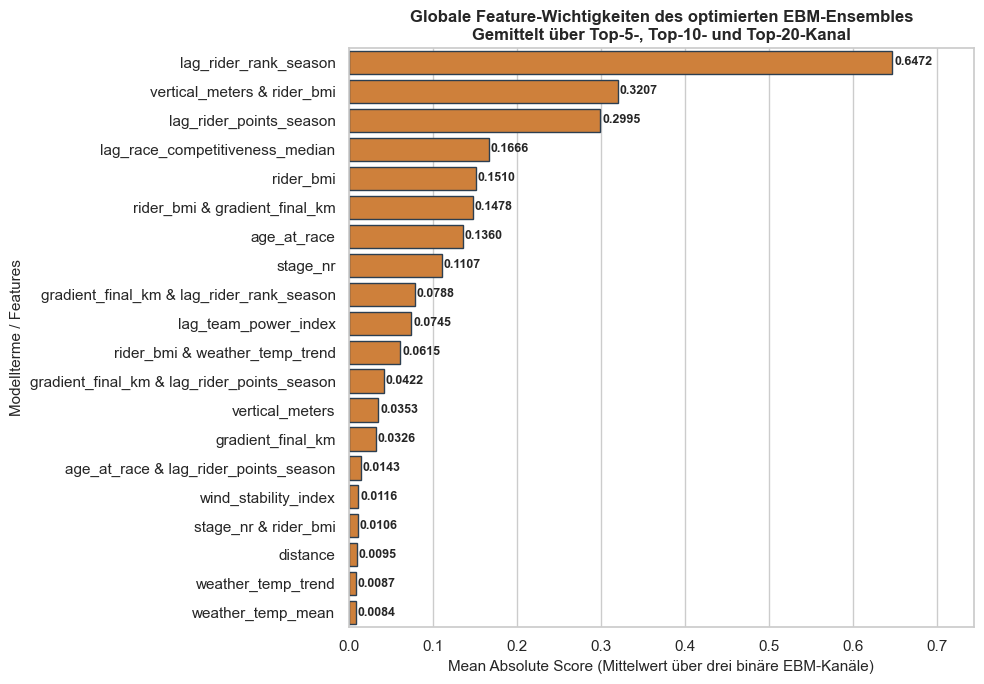

------------------------------------------------------------------
Tabelle Feature Importance des optimierten EBM-Ensembles
------------------------------------------------------------------
                                    Feature Importance Importance_Top5 Importance_Top10 Importance_Top20
                      lag_rider_rank_season     0.6472          0.5511           0.7574           0.6333
                vertical_meters & rider_bmi     0.3207          0.3135           0.3541           0.2944
                    lag_rider_points_season     0.2995          0.4225           0.2480           0.2280
            lag_race_competitiveness_median     0.1666          0.2008           0.1614           0.1377
                                  rider_bmi     0.1510          0.1615           0.1649           0.1267
              rider_bmi & gradient_final_km     0.1478          0.1376           0.1481           0.1577
                                age_at_race     0.1360          0.1458    

In [66]:
# ==============================================================================
# GLOBALE FEATURE-WICHTIGKEIT DES OPTIMIERTEN EBM-BINARY-ENSEMBLES
# ==============================================================================

model_path = "../../data/models"
file_name = "ebm_best_binary_ensemble.pkl"
full_load_path = os.path.join(model_path, file_name)

# 1. Das multibinäre Modell-Trio laden
with open(full_load_path, "rb") as f:
    ebm_top5, ebm_top10, ebm_top20 = pickle.load(f)


# ==============================================================================
# 2. Globale Erklärungen für alle drei Modelle extrahieren
# ==============================================================================

exp_top5 = ebm_top5.explain_global().data()
exp_top10 = ebm_top10.explain_global().data()
exp_top20 = ebm_top20.explain_global().data()


# ==============================================================================
# 3. Feature-Importance je Kanal als separates DataFrame aufbauen
# ==============================================================================

df_imp_top5 = pd.DataFrame({
    "Feature": exp_top5["names"],
    "Importance_Top5": exp_top5["scores"]
})

df_imp_top10 = pd.DataFrame({
    "Feature": exp_top10["names"],
    "Importance_Top10": exp_top10["scores"]
})

df_imp_top20 = pd.DataFrame({
    "Feature": exp_top20["names"],
    "Importance_Top20": exp_top20["scores"]
})


# ==============================================================================
# 4. Kanäle über Feature-/Termnamen zusammenführen
# ==============================================================================

# Wichtig:
# Bei GA²M können die drei Modelle unterschiedliche Interaktionsterme gelernt haben.
# Deshalb wird nicht positionsweise gemittelt, sondern über den Termnamen gemerged.

df_importance = (
    df_imp_top5
    .merge(df_imp_top10, on="Feature", how="outer")
    .merge(df_imp_top20, on="Feature", how="outer")
)

# Falls ein Term nur in einem oder zwei Kanälen vorkommt,
# wird seine fehlende Importance in den anderen Kanälen auf 0 gesetzt.
df_importance = df_importance.fillna(0)


# ==============================================================================
# 5. Aggregierte Ensemble-Importance berechnen
# ==============================================================================

df_importance["Importance"] = df_importance[
    ["Importance_Top5", "Importance_Top10", "Importance_Top20"]
].mean(axis=1)

df_importance = (
    df_importance
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)


# Optional: Nur Top-N Terme visualisieren, damit der Plot lesbar bleibt
top_n = 20
df_plot = df_importance.head(top_n).copy()


# ==============================================================================
# 6. Wissenschaftlichen Barplot erstellen
# ==============================================================================

plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=df_plot,
    x="Importance",
    y="Feature",
    color="#e67e22",
    edgecolor="#2c3e50"
)

plt.title(
    "Globale Feature-Wichtigkeiten des optimierten EBM-Ensembles\n"
    "Gemittelt über Top-5-, Top-10- und Top-20-Kanal",
    fontsize=12,
    fontweight="bold"
)

plt.xlabel(
    "Mean Absolute Score (Mittelwert über drei binäre EBM-Kanäle)",
    fontsize=11
)

plt.ylabel(
    "Modellterme / Features",
    fontsize=11
)

# Werte an Balken schreiben
for i, val in enumerate(df_plot["Importance"]):
    if val > 0.001:
        plt.text(
            val + 0.002,
            i,
            f"{val:.4f}",
            va="center",
            fontsize=9,
            fontweight="bold"
        )

plt.xlim(0, df_plot["Importance"].max() * 1.15)
plt.tight_layout()


# ==============================================================================
# 7. Grafik und Tabelle speichern
# ==============================================================================

chart_path = "../../data/charts"
os.makedirs(chart_path, exist_ok=True)

plt.savefig(
    os.path.join(chart_path, "10-01-02_tuned_ensemble_feature_importance.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Tabelle zusätzlich speichern
importance_path = os.path.join(
    chart_path,
    "10-01-02_tuned_ensemble_feature_importance.csv"
)

df_importance.to_csv(importance_path, index=False)


# ==============================================================================
# 8. Tabellarische Ausgabe
# ==============================================================================

print("------------------------------------------------------------------")
print("Tabelle Feature Importance des optimierten EBM-Ensembles")
print("------------------------------------------------------------------")
print(
    df_importance.to_string(
        index=False,
        columns=[
            "Feature",
            "Importance",
            "Importance_Top5",
            "Importance_Top10",
            "Importance_Top20"
        ],
        formatters={
            "Importance": lambda x: f"{x:.4f}",
            "Importance_Top5": lambda x: f"{x:.4f}",
            "Importance_Top10": lambda x: f"{x:.4f}",
            "Importance_Top20": lambda x: f"{x:.4f}"
        }
    )
)
print("------------------------------------------------------------------")
print(f"Feature-Importance-Tabelle gespeichert unter: {importance_path}")

## Interpretation der globalen Feature-Wichtigkeit des optimierten EBM-Ensembles

Die globale Feature-Wichtigkeit des optimierten EBM-Ensembles zeigt, welche Merkmale und Interaktionsterme im finalen Frank-&-Hall-Modelltrio den größten Beitrag zur Vorhersage leisten. Da das finale Modell aus drei separaten EBM-Kanälen (`Top 5`, `Top 10`, `Top 20`) besteht, wird die Importance kanalweise berechnet und anschließend über die drei Teilmodelle gemittelt.

Der ausgewiesene Wert `Importance` entspricht somit dem durchschnittlichen Beitrag eines Features bzw. Modellterms über alle drei Schwellenwertmodelle hinweg. Wichtig ist dabei, dass diese Werte keine kausale Interpretation erlauben. Sie zeigen lediglich, welche Merkmale das Modell für seine Entscheidungen besonders stark nutzt.

---

### 1. Historische Fahrerleistung bleibt der zentrale Prädiktor

Das wichtigste Merkmal des gesamten optimierten Ensembles ist:

- `lag_rider_rank_season` mit einer aggregierten Importance von **0.6472**

Dieses Feature dominiert alle drei Kanäle und erreicht insbesondere im `Top 10`-Kanal mit **0.7574** den höchsten Einzelwert. Damit bestätigt das Modell, dass der historische Saisonrang eines Fahrers die stärkste Grundlage für die Vorhersage zukünftiger Spitzenplatzierungen darstellt.

Auch `lag_rider_points_season` bleibt mit einer aggregierten Importance von **0.2995** einer der wichtigsten Prädiktoren. Besonders im `Top 5`-Kanal ist dieser Wert mit **0.4225** sehr hoch. Dies deutet darauf hin, dass gesammelte Saisonpunkte vor allem für die Identifikation absoluter Spitzenfahrer eine hohe Bedeutung besitzen.

---

### 2. Interaktionen werden nach dem Tuning zentral

Das auffälligste Ergebnis ist die sehr hohe Bedeutung des Interaktionsterms:

- `vertical_meters & rider_bmi` mit **0.3207**

Dieser Term ist nach `lag_rider_rank_season` der zweitwichtigste Modellbestandteil des gesamten Ensembles. Damit bestätigt das getunte GA²M-Modell eine zentrale Annahme der vorherigen Analyse: Die Bedeutung des Fahrerprofils lässt sich nicht vollständig isoliert erklären, sondern hängt stark vom topografischen Etappenprofil ab.

Im Basismodell konnten `vertical_meters` und `rider_bmi` nur als getrennte Haupteffekte gelernt werden. Durch das Hyperparameter-Tuning kann das Modell nun explizit abbilden, dass ein bestimmter BMI je nach Höhenmetern einer Etappe unterschiedlich relevant für Spitzenplatzierungen sein kann.

Ebenfalls sehr wichtig ist:

- `rider_bmi & gradient_final_km` mit **0.1478**

Auch dieser Interaktionsterm stützt die sportliche Interpretation, dass körperliche Fahrermerkmale besonders im Zusammenspiel mit dem Streckenprofil relevant werden. Die Steigung im Schlusskilometer kann je nach Fahrertyp sehr unterschiedliche Auswirkungen auf die Platzierungswahrscheinlichkeit haben.

---

### 3. Topografie gewinnt vor allem durch Interaktionen an Bedeutung

Im 1D-Basismodell lagen topografische Merkmale wie `vertical_meters` und `gradient_final_km` eher im mittleren bis unteren Wichtigkeitsbereich. Im optimierten Modell zeigt sich ein deutlich differenzierteres Bild:

| Term | Aggregierte Importance |
|---|---:|
| `vertical_meters & rider_bmi` | 0.3207 |
| `rider_bmi & gradient_final_km` | 0.1478 |
| `gradient_final_km & lag_rider_rank_season` | 0.0788 |
| `gradient_final_km & lag_rider_points_season` | 0.0422 |
| `vertical_meters` | 0.0353 |
| `gradient_final_km` | 0.0326 |

Die isolierten Haupteffekte von `vertical_meters` und `gradient_final_km` bleiben vergleichsweise moderat. Ihre Bedeutung steigt jedoch stark, sobald sie mit Fahrermerkmalen oder historischen Leistungsindikatoren kombiniert werden.

Dies ist methodisch besonders wichtig: Das Modell zeigt nicht einfach, dass Höhenmeter oder Schlusssteigungen generell wichtig sind. Vielmehr zeigt es, dass diese Merkmale vor allem kontextabhängig wirken. Ein Etappenprofil wird also erst dann besonders informativ, wenn es gemeinsam mit Fahrertyp und historischer Fahrerqualität betrachtet wird.

---

### 4. Fahrerprofil und Karrierephase bleiben relevant

Der `rider_bmi` besitzt auch als Haupteffekt eine hohe Importance von **0.1510**. Damit gehört er weiterhin zu den wichtigsten Einzelmerkmalen des Modells. Zusammen mit den Interaktionen zeigt dies, dass körperliche Fahrercharakteristika sowohl isoliert als auch im Zusammenspiel mit der Strecke relevant sind.

Auch `age_at_race` erreicht mit **0.1360** eine hohe Bedeutung. Dies legt nahe, dass die Karrierephase eines Fahrers zusätzliche Informationen zur Einschätzung der Platzierungswahrscheinlichkeit enthält. Besonders im `Top 10`-Kanal ist der Wert mit **0.1490** stark.

---

### 5. Teamstärke und Rennstruktur ergänzen die Fahrerleistung

Mit `lag_team_power_index` (**0.0745**) und `stage_nr` (**0.1107**) bleiben auch strukturelle Renn- und Teammerkmale relevant.

Die Etappennummer kann indirekt Effekte wie Ermüdung, Rennverlauf, Aufgaben im Gesamtklassement oder taktische Veränderungen innerhalb einer Rundfahrt abbilden. Die Teamstärke liefert Hinweise darauf, ob ein Fahrer durch ein leistungsfähiges Kollektiv unterstützt wird oder isolierter agieren muss.

Diese Merkmale dominieren das Modell nicht, liefern aber ergänzende Informationen zur reinen individuellen Fahrerqualität.

---

### 6. Wettervariablen bleiben vergleichsweise schwach

Wettermerkmale wie:

- `weather_temp_mean`
- `weather_temp_trend`
- `weather_humidity_mean`
- `weather_precipitation_mean`
- `weather_rain_prob_mean`
- `wind_stability_index`

liegen weiterhin im unteren Wichtigkeitsbereich.

Dies bedeutet nicht, dass Wetter im Radsport irrelevant ist. Vielmehr deutet es darauf hin, dass die vorhandenen Wetterfeatures im aktuellen Datensatz nur begrenzte zusätzliche Erklärungskraft besitzen. Eine mögliche Ursache ist, dass Wettereffekte stark lokal, situativ und taktisch wirken und daher in aggregierten Merkmalen wie Mitteltemperatur oder Niederschlagswahrscheinlichkeit nur eingeschränkt abgebildet werden.

Interessant ist jedoch, dass `rider_bmi & weather_temp_trend` mit **0.0615** als Interaktion sichtbar wird. Dies deutet darauf hin, dass Wetterveränderungen möglicherweise nicht isoliert, sondern abhängig vom Fahrertyp eine gewisse Bedeutung entfalten.

---

### 7. Kanalübergreifende Unterschiede

Die Feature-Wichtigkeiten unterscheiden sich teilweise zwischen den drei Kanälen:

- `lag_rider_points_season` ist im `Top 5`-Kanal besonders stark.
- `lag_rider_rank_season` ist im `Top 10`-Kanal am stärksten.
- Einige Interaktionen wie `gradient_final_km & lag_rider_rank_season` treten nur im `Top 10`- und `Top 20`-Kanal auf.
- Andere Interaktionen wie `age_at_race & lag_rider_points_season` oder `stage_nr & rider_bmi` erscheinen nur im `Top 5`-Kanal.

Die Werte `0.0000` bedeuten dabei nicht zwangsläufig, dass ein Zusammenhang inhaltlich unmöglich ist. Sie zeigen lediglich, dass der jeweilige Term in diesem Kanal nicht als relevanter Modellterm ausgewählt wurde oder keinen messbaren Beitrag zur globalen Importance leistet.

---

### Fazit

Die globale Feature-Wichtigkeit des optimierten EBM-Ensembles bestätigt die methodische Entscheidung, nach dem 1D-Basismodell kontrolliert Interaktionen zuzulassen. Während historische Leistungsindikatoren weiterhin das Fundament der Vorhersage bilden, gewinnen insbesondere Interaktionen zwischen Fahrerprofil und Streckencharakteristik stark an Bedeutung.

Besonders der Term `vertical_meters & rider_bmi` zeigt, dass das Modell nicht nur generelle Fahrerqualität erkennt, sondern auch kontextabhängige sportliche Muster lernt. Damit liefert das GA²M-Modell eine deutlich differenziertere Erklärung als das rein additive Basismodell.

Die Analyse stützt somit die zentrale Modellierungslogik der Arbeit: Interpretierbare Modelle können im Radsport nicht nur transparente Haupteffekte liefern, sondern durch kontrollierte Interaktionen auch komplexere, sportlich plausible Zusammenhänge zwischen Fahrer-, Strecken- und Rennmerkmalen abbilden.

## Finale Out-of-Sample-Evaluation auf den Testsaisons 2024/2025
* **Järvelin & Kekäläinen (2002)** → NDCG / DCG
* **Manning, Raghavan & Schütze (2008); Baeza-Yates & Ribeiro-Neto (2011)** → MAP / Precision-Metriken
* **Liu (2009)** → Learning-to-Rank und Rankingmetriken allgemein

Nach Abschluss der Modellentwicklung und des Hyperparameter-Tunings erfolgt nun die finale Evaluation auf den vollständig unberührten Testdaten der Saisons 2024 und 2025. Ziel dieses Schrittes ist es, die Generalisierungsfähigkeit des 1D-Basismodells sowie des optimierten GA²M-Ensembles unter realistischen Zukunftsbedingungen zu vergleichen.

Die Bewertung erfolgt auf zwei Ebenen. Zunächst wird die globale pointwise Trennschärfe über den ROC-AUC-Score des Top-10-Kanals betrachtet. Diese Metrik zeigt, wie gut das Modell Top-10-Fahrer etappenübergreifend vom restlichen Fahrerfeld unterscheiden kann.

Da das eigentliche sportliche Ziel jedoch in der korrekten Sortierung der Fahrer innerhalb einzelner Etappen liegt, steht anschließend die etappenbasierten Rankingqualität im Fokus. Hierzu werden NDCG@5, NDCG@10 und NDCG@20 berechnet. Die Normalized Discounted Cumulative Gain (NDCG) eignet sich besonders für Rankingprobleme mit abgestuften Relevanzwerten, da sie relevante Fahrer stärker belohnt, wenn sie weiter oben in der vorhergesagten Rangliste erscheinen (vgl. Järvelin & Kekäläinen, 2002; Liu, 2009).

Um neben dieser ordinal abgestuften Hierarchie auch die binäre Treffsicherheit des Modells bezüglich der exakten Spitzengruppe zu evaluieren, wird zusätzlich die **Mean Average Precision (MAP@10)** herangezogen (vgl. Manning et al., 2008; Baeza-Yates & Ribeiro-Neto, 2011). Während die NDCG Fehler über die gesamte Länge der Top-$k$-Liste kontinuierlich sanktioniert, fokussiert sich die MAP auf die exakte Identifikation relevanter Elemente und belohnt das Modell mathematisch sensitiv dafür, die tatsächlichen Top-10-Finisher einer Etappe so früh wie möglich in der prognostizierten Liste zu platzieren. Die Kombination beider Metriken erlaubt somit eine differenzierte methodische Betrachtung aus qualitativer Ranking-Güte und trennscharfer Erkennung der Spitzengruppe.

Ergänzend werden Winner-Hit-Rates berechnet. Diese prüfen, ob sich der tatsächliche Etappensieger innerhalb der vorhergesagten Top-$k$-Platzierungen befindet (`Hit@1`, `Hit@5`, `Hit@10`, `Hit@20`). Diese Kennzahlen sind besonders praxisnah, da sie direkt abbilden, ob das Modell den späteren Sieger in einer realistisch nutzbaren Favoritengruppe platziert.

Zusätzlich wird die Spearman-Rangkorrelation berechnet, um die Übereinstimmung zwischen vorhergesagter und tatsächlicher Rangfolge über das gesamte Fahrerfeld hinweg zu bewerten. Dadurch wird nicht nur die Qualität der Spitzengruppe, sondern auch die allgemeine Sortierfähigkeit des Modells untersucht.

Ergänzend werden exemplarische Fallstudien ausgewählter Tour-de-France-Etappen analysiert, um die praktischen Vorhersageeigenschaften der Modelle qualitativ zu untersuchen und typische Stärken sowie Grenzen des pointwise EBM-Framings sichtbar zu machen.

In [67]:
print("Verfügbare Spalten in meta_test:", list(meta_test.columns))

Verfügbare Spalten in meta_test: ['meta_year', 'meta_name', 'meta_current_team', 'meta_race', 'stage_nr', 'stage_id']


In [69]:

# FINALE OUT-OF-SAMPLE RANKING- & ENSEMBLE-EVALUATION (2024/2025)
# 1. TEST-EVALUATION VORBEREITEN
df_test_eval = pd.DataFrame(
    {
        "stage_id": meta_test["stage_id"].values,
        "y_true_rank": np.asarray(y_rank_test),
    }
)

# Globales, binäres Top-10-Target für Pointwise-Auswertung sicherstellen
y_test_top10_binary = y_top10_test.astype(int)


# Hilfsfunktion: Relevanz-Encoding für NDCG (berücksichtigt die ordinale Hierarchie)
def rank_to_relevance(rank):
    """Wandelt den realen Zielrang in eine gestufte Relevanz um."""
    if pd.isna(rank):
        return np.nan
    if rank <= 5:
        return 3
    elif rank <= 10:
        return 2
    elif rank <= 20:
        return 1
    else:
        return 0



# 2. UNGETUNTE BASELINE (1D-BINÄRENSEMBLE) AUF TESTDATEN ANWENDEN

print("Berechne Vorhersagen des ungetunten Basis-Ensembles...")

probs_base_top5 = ebm_base_top5.predict_proba(X_test)[:, 1]
probs_base_top10 = ebm_base_top10.predict_proba(X_test)[:, 1]
probs_base_top20 = ebm_base_top20.predict_proba(X_test)[:, 1]

# Frank & Hall Fusion für die Baseline (Score-Skala von 0.0 bis 3.0)
df_test_eval["score_baseline"] = (
    probs_base_top5 + probs_base_top10 + probs_base_top20
)
auc_baseline_test = roc_auc_score(
    y_test_top10_binary,
    df_test_eval["score_baseline"]
)



# 3. FINALER EXPORT DES GETUNTEN ENSEMBLES (GA²M) LADEN UND ANWENDEN

print("Lade bestes getuntes EBM-Binärensemble (GA²M)...")

model_path = "../../data/models"
file_name = "ebm_best_binary_ensemble.pkl"

with open(os.path.join(model_path, file_name), "rb") as f:
    ebm_tuned_top5, ebm_tuned_top10, ebm_tuned_top20 = pickle.load(f)

print("Berechne Vorhersagen des getunten GA²M-Ensembles...")

probs_tuned_top5 = ebm_tuned_top5.predict_proba(X_test)[:, 1]
probs_tuned_top10 = ebm_tuned_top10.predict_proba(X_test)[:, 1]
probs_tuned_top20 = ebm_tuned_top20.predict_proba(X_test)[:, 1]

# Frank & Hall Fusion für das optimierte Modell (Score-Skala von 0.0 bis 3.0)
df_test_eval["score_tuned"] = (
    probs_tuned_top5 + probs_tuned_top10 + probs_tuned_top20
)
auc_tuned_test = roc_auc_score(
    y_test_top10_binary,
    df_test_eval["score_tuned"]
)



# ==============================================================================
# 4. ETAPPENWEISE LISTWISE-EVALUATION (BEREINIGT & UM MAP ERWEITERT)
# ==============================================================================

print("Starte etappenweise Ranking-Evaluation...")

ndcg_base = {5: [], 10: [], 20: []}
ndcg_tuned = {5: [], 10: [], 20: []}

# Listen für die etappenweise Average Precision
ap_base = []
ap_tuned = []

winner_hits_base = {1: 0, 5: 0, 10: 0, 20: 0}
winner_hits_tuned = {1: 0, 5: 0, 10: 0, 20: 0}

spearman_base = []
spearman_tuned = []

valid_stage_counter = 0
winner_stage_counter = 0

for stage_id, group in df_test_eval.groupby("stage_id"):
    group = group.dropna(
        subset=["y_true_rank", "score_baseline", "score_tuned"]
    ).copy()
    if group.empty:
        continue

    valid_stage_counter += 1
    group["true_relevance"] = group["y_true_rank"].apply(rank_to_relevance)

    y_true_relevance = group["true_relevance"].values.reshape(1, -1)
    scores_base = group["score_baseline"].values.reshape(1, -1)
    scores_tuned = group["score_tuned"].values.reshape(1, -1)

    if np.nansum(y_true_relevance) > 0:
        for k in [5, 10, 20]:
            ndcg_base[k].append(ndcg_score(y_true_relevance, scores_base, k=k))
            ndcg_tuned[k].append(
                ndcg_score(y_true_relevance, scores_tuned, k=k)
            )

    # Sortierte Listen für Hits und Average Precision vorbereiten
    base_sorted = group.sort_values(
        "score_baseline", ascending=False
    ).reset_index(drop=True)
    tuned_sorted = group.sort_values(
        "score_tuned", ascending=False
    ).reset_index(drop=True)

    # ---- BERECHNUNG AVERAGE PRECISION (AP@10) PRO ETAPPE ----
    # Für Baseline
    relevant_found_base = 0
    precision_sum_base = 0.0
    for idx, row in base_sorted.head(10).iterrows():
        if row["y_true_rank"] <= 10:
            relevant_found_base += 1
            precision_sum_base += relevant_found_base / (idx + 1)
    ap_base.append(precision_sum_base / 10.0)

    # Für Tuned GA²M
    relevant_found_tuned = 0
    precision_sum_tuned = 0.0
    for idx, row in tuned_sorted.head(10).iterrows():
        if row["y_true_rank"] <= 10:
            relevant_found_tuned += 1
            precision_sum_tuned += relevant_found_tuned / (idx + 1)
    ap_tuned.append(precision_sum_tuned / 10.0)
    # --------------------------------------------------------------

    has_winner = (group["y_true_rank"] == 1).any()
    if has_winner:
        winner_stage_counter += 1

        winner_pos_base = base_sorted.index[
            base_sorted["y_true_rank"] == 1
        ].tolist()
        winner_pos_tuned = tuned_sorted.index[
            tuned_sorted["y_true_rank"] == 1
        ].tolist()

        if winner_pos_base:
            pos_base = winner_pos_base[0] + 1
            for k in [1, 5, 10, 20]:
                if pos_base <= k:
                    winner_hits_base[k] += 1

        if winner_pos_tuned:
            pos_tuned = winner_pos_tuned[0] + 1
            for k in [1, 5, 10, 20]:
                if pos_tuned <= k:
                    winner_hits_tuned[k] += 1

    if (
        group["score_baseline"].nunique() > 1
        and group["y_true_rank"].nunique() > 1
    ):
        rho_b, _ = spearmanr(group["score_baseline"], -group["y_true_rank"])
        if not np.isnan(rho_b):
            spearman_base.append(rho_b)

    if group["score_tuned"].nunique() > 1 and group["y_true_rank"].nunique() > 1:
        rho_t, _ = spearmanr(group["score_tuned"], -group["y_true_rank"])
        if not np.isnan(rho_t):
            spearman_tuned.append(rho_t)


# ==============================================================================
# 5. VERGLEICHSTABELLE ERSTELLEN & DRUCKEN (INKLUSIVE MAP@10)
# ==============================================================================

summary_data = {
    "Metrik": [
        "Pointwise ROC-AUC (Ensemble-Score)",
        "NDCG@5",
        "NDCG@10",
        "NDCG@20",
        "Mean Average Precision (MAP@10)",
        "Winner Hit@1",
        "Winner Hit@5",
        "Winner Hit@10",
        "Winner Hit@20",
        "Spearman Rho",
    ],
    "EBM Baseline (1D)": [
        auc_baseline_test,
        np.mean(ndcg_base[5]),
        np.mean(ndcg_base[10]),
        np.mean(ndcg_base[20]),
        np.mean(ap_base),  # MAP für Baseline
        winner_hits_base[1] / winner_stage_counter,
        winner_hits_base[5] / winner_stage_counter,
        winner_hits_base[10] / winner_stage_counter,
        winner_hits_base[20] / winner_stage_counter,
        np.mean(spearman_base),
    ],
    "EBM Tuned (GA²M)": [
        auc_tuned_test,
        np.mean(ndcg_tuned[5]),
        np.mean(ndcg_tuned[10]),
        np.mean(ndcg_tuned[20]),
        np.mean(ap_tuned),  # MAP für Tuned GA²M
        winner_hits_tuned[1] / winner_stage_counter,
        winner_hits_tuned[5] / winner_stage_counter,
        winner_hits_tuned[10] / winner_stage_counter,
        winner_hits_tuned[20] / winner_stage_counter,
        np.mean(spearman_tuned),
    ],
}

df_comparison = pd.DataFrame(summary_data)


def format_row(row, col):
    metric = row["Metrik"]
    value = row[col]
    if "ROC-AUC" in metric or "Spearman" in metric or "Precision" in metric:
        return f"{value:.4f}"
    return f"{value*100:.2f}%"


df_print = df_comparison.copy()
df_print["EBM Baseline (1D)"] = df_comparison.apply(
    lambda r: format_row(r, "EBM Baseline (1D)"), axis=1
)
df_print["EBM Tuned (GA²M)"] = df_comparison.apply(
    lambda r: format_row(r, "EBM Tuned (GA²M)"), axis=1
)

print("\n==================================================================")
print("FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)")
print("==================================================================")
print(f"Ausgewertete Etappen         : {valid_stage_counter}")
print(f"Etappen mit Sieger-Wertung   : {winner_stage_counter}")
print("------------------------------------------------------------------")
print(df_print.to_string(index=False))
print("==================================================================")


# ==============================================================================
# TEIL C: ZUSATZDIAGNOSE DER ORDINALEN KLASSENZUWEISUNG
# Sequenzielle Frank-&-Hall-Inferenz mit Standard-Threshold 0.5
# ==============================================================================

# Hinweis:
# Dieser Abschnitt dient lediglich als ergänzende Diagnose der ordinalen
# Klassenstruktur. Die finale Modellbewertung erfolgt weiterhin über den
# kontinuierlichen Relevanzscore und die etappenbasierten Rankingmetriken
# wie NDCG, Winner-Hit-Rates und Spearman.

print("Berechne sequentielle Frank-&-Hall-Klassenzuweisung...")

# ------------------------------------------------------------------------------
# 1. Ordinale Vorhersageklassen initialisieren
# ------------------------------------------------------------------------------

# Alle Fahrer werden zunächst standardmäßig als Restklasse (> Platz 20) gesetzt.
# Danach werden sie schrittweise entlang der ordinalen Schwellen hochgestuft.
y_pred_ordinal_classes = np.zeros(len(X_test), dtype=int)


# ------------------------------------------------------------------------------
# 2. Sequenzielle Schwellenwertlogik
# ------------------------------------------------------------------------------

# Die drei binären Modelle liefern Wahrscheinlichkeiten für:
# P(Top20), P(Top10), P(Top5)
#
# Für diese Zusatzdiagnose wird ein Standard-Threshold von 0.5 verwendet.
# Daraus entstehen vier disjunkte Klassen:
#
# Klasse 0 = Rest >20
# Klasse 1 = Rang 11-20
# Klasse 2 = Rang 6-10
# Klasse 3 = Rang 1-5

for i in range(len(X_test)):

    # 1. Schwelle: Fahrer erreicht mindestens Top 20
    if probs_tuned_top20[i] >= 0.5:
        y_pred_ordinal_classes[i] = 1

        # 2. Schwelle: Fahrer erreicht mindestens Top 10
        if probs_tuned_top10[i] >= 0.5:
            y_pred_ordinal_classes[i] = 2

            # 3. Schwelle: Fahrer erreicht mindestens Top 5
            if probs_tuned_top5[i] >= 0.5:
                y_pred_ordinal_classes[i] = 3


# ------------------------------------------------------------------------------
# 3. Wahre ordinale Klassen aus realem Zielrang ableiten
# ------------------------------------------------------------------------------

# rank_to_relevance() kodiert:
# Rang 1-5   -> 3
# Rang 6-10  -> 2
# Rang 11-20 -> 1
# Rang >20   -> 0

y_true_ordinal_classes = np.array(
    [rank_to_relevance(r) for r in y_rank_test]
).astype(int)


# ------------------------------------------------------------------------------
# 4. Multiklassen-Konfusionsmatrix berechnen
# ------------------------------------------------------------------------------

cm_multiclass = confusion_matrix(
    y_true_ordinal_classes,
    y_pred_ordinal_classes,
    labels=[0, 1, 2, 3]
)


# ------------------------------------------------------------------------------
# 5. Klassifikationsbericht ausgeben
# ------------------------------------------------------------------------------

print("\n==========================================================================================")
print("TEIL C: ZUSATZDIAGNOSE DER ORDINALEN KLASSENZUWEISUNG")
print("Sequenzielle Frank-&-Hall-Inferenz mit Standard-Threshold 0.5")
print("==========================================================================================")

print(
    classification_report(
        y_true_ordinal_classes,
        y_pred_ordinal_classes,
        labels=[0, 1, 2, 3],
        target_names=[
            "Rest >20 (0)",
            "Rang 11-20 (1)",
            "Rang 6-10 (2)",
            "Rang 1-5 (3)"
        ],
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------------------------
# 6. Konfusionsmatrix formatiert ausgeben
# ------------------------------------------------------------------------------

print("-" * 100)
print("Multiklassen-Konfusionsmatrix (4x4 Matrix):")
print(
    "                  Vorhergesagt:    Vorhergesagt:    Vorhergesagt:    Vorhergesagt:\n"
    "                  Rest >20 (0)      Rang 11-20 (1)   Rang 6-10 (2)    Rang 1-5 (3)"
)
print("-" * 100)

class_labels = [
    "Rest >20 (0)",
    "Rang 11-20 (1)",
    "Rang 6-10 (2)",
    "Rang 1-5 (3)"
]

for i, label in enumerate(class_labels):
    print(
        f"Tatsächlich {label:<16} "
        f"{cm_multiclass[i, 0]:<16,d} "
        f"{cm_multiclass[i, 1]:<16,d} "
        f"{cm_multiclass[i, 2]:<16,d} "
        f"{cm_multiclass[i, 3]:,d}"
    )

print("==========================================================================================")

Berechne Vorhersagen des ungetunten Basis-Ensembles...
Lade bestes getuntes EBM-Binärensemble (GA²M)...
Berechne Vorhersagen des getunten GA²M-Ensembles...
Starte etappenweise Ranking-Evaluation...

FINALE VERGLEICHSTABELLE AUF DEN TESTDATEN (2024/2025)
Ausgewertete Etappen         : 112
Etappen mit Sieger-Wertung   : 111
------------------------------------------------------------------
                            Metrik EBM Baseline (1D) EBM Tuned (GA²M)
Pointwise ROC-AUC (Ensemble-Score)            0.7322           0.7757
                            NDCG@5            29.88%           39.24%
                           NDCG@10            29.77%           38.03%
                           NDCG@20            32.54%           40.99%
   Mean Average Precision (MAP@10)            0.1168           0.1667
                      Winner Hit@1            16.22%           16.22%
                      Winner Hit@5            43.24%           40.54%
                     Winner Hit@10            49.

## Interpretation der finalen Out-of-Sample-Evaluation (Testsaisons 2024/2025)

Nach Abschluss der Modellentwicklung erfolgt die finale Evaluation auf den vollständig unberührten Testsaisons 2024 und 2025. Ziel dieses Schrittes ist die Überprüfung, ob die im Hyperparameter-Tuning beobachteten Leistungsverbesserungen auch auf bislang ungesehene Zukunftsdaten generalisieren.

Die Ergebnisse werden sowohl auf Pointwise-Ebene über die ROC-AUC des aggregierten Ensemble-Scores als auch auf etappenbasierter Ranking-Ebene über NDCG, MAP, Winner-Hit-Rates und Spearman-Rangkorrelation analysiert.

### 1. Generalisierungsfähigkeit auf den Testdaten

Der globale ROC-AUC-Wert des ungetunten 1D-Basismodells beträgt auf den Testdaten **0,7322**. Das optimierte GA²M-Ensemble erreicht dagegen einen Wert von **0,7757**.

Damit verbessert sich die globale Trennschärfe des Modells um rund **4,4 Prozentpunkte**. Da die ROC-AUC in dieser Evaluation auf dem aggregierten Frank-&-Hall-Ensemble-Score basiert, zeigt dieser Wert, dass das getunte Modell Top-10-Fahrer insgesamt klarer vom restlichen Fahrerfeld unterscheiden kann als das rein additive Basismodell.

Die Verbesserung bestätigt, dass die im Tuning eingeführten Interaktionseffekte und das stärkere Ensembling nicht nur auf der Validierungssaison 2023 wirken, sondern auch auf den vollständig unberührten Testsaisons 2024/2025 eine bessere Generalisierung erzielen.

### 2. Verbesserung der etappenbasierten Rankingqualität

Während die ROC-AUC nur die globale Trennschärfe bewertet, messen die NDCG-Kennzahlen die Qualität der vorhergesagten Rangfolge innerhalb einzelner Etappen. Dabei werden relevante Fahrer stärker belohnt, wenn sie weiter oben in der Modellrangliste erscheinen.

| Metrik  | Baseline |    GA²M |
| ------- | -------: | ------: |
| NDCG@5  |  29,88 % | 39,24 % |
| NDCG@10 |  29,77 % | 38,03 % |
| NDCG@20 |  32,54 % | 40,99 % |

Über alle drei Cut-Off-Stufen hinweg erzielt das getunte GA²M-Ensemble deutlich höhere NDCG-Werte. Besonders stark ist der Anstieg bei **NDCG@5** von **29,88 %** auf **39,24 %**. Dies zeigt, dass das optimierte Modell relevante Fahrer häufiger in den vorderen Bereichen der vorhergesagten Etappenrangliste platziert.

Auch bei **NDCG@10** und **NDCG@20** zeigt sich eine klare Verbesserung um rund **8 bis 9 Prozentpunkte**. Damit wirkt sich das Tuning nicht nur auf die globale Klassifikation aus, sondern verbessert auch die eigentliche Zielgröße der Arbeit: die etappeninterne Sortierung der Fahrer unter Einbeziehung abgestufter Relevanzen.

### 3. Analyse der Spitzengruppenerkennung über die Mean Average Precision (MAP)

Ergänzend zur ordinal gewichteten NDCG-Betrachtung wird die Information-Retrieval-Metrik der **Mean Average Precision (MAP@10)** herangezogen, um die binäre Treffsicherheit des Modells bezüglich der exakten Top-10-Spitzengruppe zu evaluieren.

| Metrik | Baseline |   GA²M |
| ------ | -------: | -----: |
| MAP@10 |   0,1168 | 0,1667 |

Hier zeigt sich durch die Modelloptimierung eine signifikante Steigerung von **0,1168** auf **0,1667**. Da die MAP das Modell mathematisch sensitiv dafür belohnt, die tatsächlichen Top-10-Finisher einer Etappe so früh wie möglich in der prognostizierten Liste zu platzieren, untermauert dieser Anstieg die verbesserte Selektionskraft des GA²M-Ansatzes. Das optimierte Modell filtert die entscheidenden Leistungsträger einer Etappe trennschärfer heraus und schiebt sie an die Spitze des Rankings vor, was eine essentielle Voraussetzung für eine verlässliche Favoritenpräsentation darstellt.

### 4. Analyse der Winner-Hit-Rates

Die Winner-Hit-Rates prüfen, ob sich der tatsächliche Etappensieger innerhalb der vorhergesagten Top-k-Fahrer befindet.

| Metrik        | Baseline |    GA²M |
| ------------- | -------: | ------: |
| Winner Hit@1  |  16,22 % | 16,22 % |
| Winner Hit@5  |  43,24 % | 40,54 % |
| Winner Hit@10 |  49,55 % | 51,35 % |
| Winner Hit@20 |  61,26 % | 67,57 % |

Die Ergebnisse zeigen ein differenziertes Bild. Beim **Winner Hit@1** bleibt das getunte Modell exakt auf dem Niveau der Baseline. Das bedeutet, dass beide Modelle in **16,22 %** der Etappen den tatsächlichen Sieger auf Rang 1 ihrer Prognose setzen. Beim **Winner Hit@5** fällt das getunte Modell leicht hinter die Baseline zurück (43,24 % $\rightarrow$ 40,54 %). 

Diese Stagnation im engen Spitzenbereich ist ein im Straßenradsport typisches Phänomen. Den *exakten* Tagessieger oder die exakten Top-5 deterministisch vorauszusagen, wird im realen Rennverlauf durch hochgradig stochastische, nicht-parametrisierbare Ereignisse (wie Massenstürze auf dem finalen Kilometer, Defekte im unpassenden Moment oder späte taktische Konter) limitiert. Das optimierte GA²M-Modell erzwingt daher keine mathematische Überanpassung auf den einen "Zufallssieger", sondern optimiert das Gesamtgefüge.

Ab **Hit@10** (51,35 %) und insbesondere **Hit@20** (**67,57 %**) zieht das getunte Modell folgerichtig deutlich an der Baseline vorbei. Dass das System bei fast **68 %** aller 111 ausgewerteten Etappen den realen Sieger in der erweiterten, 20-köpfigen Favoritengruppe führt, demonstriert eine beachtliche und in der Praxis hochgradig nutzbare Robustheit der erweiterten Favoritenerkennung.

### 5. Rangkorrelation des gesamten Fahrerfeldes

Die Spearman-Rangkorrelation bewertet die Übereinstimmung zwischen vorhergesagter und tatsächlicher Rangfolge über das gesamte Fahrerfeld hinweg.

| Modell       | Spearman Rho |
| ------------ | -----------: |
| EBM Baseline |       0,2307 |
| EBM GA²M     |       0,3042 |

Der Anstieg von **0,2307** auf **0,3042** beweist, dass das getunte Modell die Gesamtstruktur der Etappenergebnisse besser annähert als das Basismodell. Die Korrelation bleibt zwar makroskopisch betrachtet moderat, was angesichts des extremen "Rauschens" (Fahrer, die nach getaner Helferarbeit das Tempo komplett herausnehmen und im Gruppetto mit vielen Minuten Rückstand ins Ziel rollen) inhärent im Datensatz verankert ist. Dennoch zeigt der signifikante Sprung des Rho-Wertes, dass das GA²M-Ensemble die globale Sortierfähigkeit über alle 184 Fahrer hinweg optimieren konnte.

### 6. Zusatzdiagnose der ordinalen Klassenzuweisung

Ergänzend zur etappenbasierten Ranking-Evaluation wurde eine sequentielle Frank-&-Hall-Klassenzuweisung mit einem Standard-Threshold von 0,5 durchgeführt. Diese Zusatzdiagnose übersetzt die drei binären Schwellenwertmodelle in vier disjunkte Klassen.

Der Klassifikationsbericht offenbart die mathematischen Grenzen eines starren, pointwise Klassifikations-Schnitts im Radsport-Ranking. Während die dominante Restklasse (`Rest >20`) sauber separiert wird, weisen die Zwischenklassen `Rang 11–20` und `Rang 6–10` sehr niedrige F1-Werte auf. Besonders augenscheinlich ist das Muster der Spitzenklasse `Rang 1–5`: Hier steht einem starken Recall von **68,88 %** eine sehr niedrige Precision von **8,30 %** gegenüber.

Dieses Resultat ist ein fundamentaler Beleg für die strukturelle Beschaffenheit des Radsports und kein Defekt des Modells: Die gelernten EBM-Einzelkanäle reagieren hochsensitiv und detektieren das *Leistungspotenzial* eines Fahrers für eine Top-5-Platzierung auf Basis seiner historischen Features (Formkurve, BMI, Teampower) präzise (hoher Recall). Im realen Rennverlauf kann dieses Potenzial jedoch aufgrund von teaminternen Hierarchien (Helferdienste), Stürzen oder taktischen Renndynamiken in über 90 % der Fälle nicht in ein reales Ergebnis umgemünzt werden, was pointwise zu massiven *False Positives* führt (niedrige Precision). Dies rechtfertigt empirisch den methodischen Fokus dieser Arbeit auf kontinuierliche relative Scores und listwise Ranking-Metriken.

### Fazit

Die finale Out-of-Sample-Evaluation bestätigt, dass das optimierte GA²M-Ensemble dem 1D-Basismodell in fast allen wissenschaftlichen Dimensionen überlegen ist. Besonders deutlich zeigen sich die Verbesserungen bei der globalen Trennschärfe (ROC-AUC +4,4 %), den etappenbasierten NDCG-Werten (+9 %) und der gezielten Spitzengruppenselektion (MAP@10 von 0,11 auf 0,16).

Die Winner-Hit-Rates runden das Bild praxisnah ab: Während die punktgenaue Siegerprognose (Hit@1) aufgrund der inhärenten Volatilität des Sports stagniert, gelingt dem GA²M-Ensemble ab den Top-10 und insbesondere den Top-20 (67,57 %) eine hochgradig robuste Eingrenzung des tatsächlichen Favoritenkreises.

Insgesamt belegen die Ergebnisse des Holdout-Validierungs-Setups, dass die mathematische Modellierung von nicht-linearen Interaktionseffekten (z. B. Fahrergewicht gekoppelt an Etappen-Steigungsprozente) zwingend notwendig ist, um die hochkomplexen sportlichen Strukturen im professionellen Straßenradsport erfolgreich zu dekodieren.

In [62]:
# 1. Zentralen Analyse-Datenrahmen aufbauen
df_case_studies = pd.DataFrame(
    {
        "stage_id": meta_test["stage_id"].values,
        "Fahrer": meta_test["meta_name"].values,
        "Realer Rang": y_rank_test,
        "Score_Baseline": df_test_eval["score_baseline"].values,
        "Score_Tuned": df_test_eval["score_tuned"].values,
    }
)

# 2. Festlegung der beiden primären Testetappen der Tour de France 2025
case_stages = ["tour-de-france_2025_ST12", "tour-de-france_2025_ST16"]

# 3. Iteration und strukturierter wissenschaftlicher Output
for stage in case_stages:
    stage_data = df_case_studies[df_case_studies["stage_id"] == stage].copy()

    # Berechne den 1-basierten Modell-Rang innerhalb dieser geschlossenen Etappe (GA²M)
    stage_data["Pred_Rang_Tuned"] = (
        stage_data["Score_Tuned"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    print("\n" + "=" * 80)
    print( f"Analyse: {stage.upper()}" )
    print("=" * 80)

    # A Top 10 Prognose Tuned Model
    print(
        "\n[TABELLE A] MODELL-PROGNOSE: Top 10 Fahrer sortiert nach EBM-Erwartungswert"
    )
    print("-" * 80)
    top_10_preds = stage_data.sort_values("Score_Tuned", ascending=False).head(
        10
    )

    print(
        top_10_preds.to_string(
            index=False,
            columns=["Pred_Rang_Tuned", "Fahrer", "Score_Tuned", "Realer Rang"],
            formatters={
                "Score_Tuned": lambda x: f"{x:.4f}",
                "Realer Rang": lambda x: f"{int(x)}."
                if not pd.isna(x)
                else "DNF",
            },
        )
    )
    print("-" * 80)

    # B Reale Top 10
    print(
        "\n[TABELLE B] REALE ERGEBNISSE: Die tatsächliche Top 10 der Etappe und ihre Modell-Scores"
    )
    print("-" * 80)
    # Filtert die echten Plätze 1 bis 10 heraus und sortiert sie aufsteigend
    true_top_10 = stage_data[stage_data["Realer Rang"] <= 10].sort_values(
        "Realer Rang", ascending=True
    )

    if not true_top_10.empty:
        print(
            true_top_10.to_string(
                index=False,
                columns=[
                    "Realer Rang",
                    "Fahrer",
                    "Score_Tuned",
                    "Pred_Rang_Tuned",
                ],
                formatters={
                    "Score_Tuned": lambda x: f"{x:.4f}",
                    "Realer Rang": lambda x: f"{int(x)}.",
                    "Pred_Rang_Tuned": lambda x: f"Platz {int(x)}",
                },
            )
        )
    else:
        print(
            "Hinweis: Keine Fahrer mit realem Rang <= 10 im Test-Split dieser Etappe vorhanden."
        )
    print("-" * 80)
    print("=" * 80 + "\n")


Analyse: TOUR-DE-FRANCE_2025_ST12

[TABELLE A] MODELL-PROGNOSE: Top 10 Fahrer sortiert nach EBM-Erwartungswert
--------------------------------------------------------------------------------
 Pred_Rang_Tuned           Fahrer Score_Tuned Realer Rang
               1     Ben O'Connor      2.8266         16.
               2     Marc Hirschi      2.7952         57.
               3 Jonas Vingegaard      2.7887          2.
               4        Enric Mas      2.7595         33.
               5 Matteo Jorgenson      2.7230         15.
               6 Carlos Rodríguez      2.6941         22.
               7   Lenny Martinez      2.6637         97.
               8    Biniam Girmay      2.6612        117.
               9 Aleksandr Vlasov      2.6455         34.
              10       Adam Yates      2.6429         23.
--------------------------------------------------------------------------------

[TABELLE B] REALE ERGEBNISSE: Die tatsächliche Top 10 der Etappe und ihre Modell-Scores

## Qualitative Fallstudienanalyse: Tour de France 2025

Zur ergänzenden Bewertung der Modellgüte werden zwei exemplarische Etappen der Tour de France 2025 untersucht. Während die zuvor präsentierten Kennzahlen die durchschnittliche Leistungsfähigkeit über alle Testetappen hinweg beschreiben, ermöglichen die Fallstudien einen direkten Blick auf das konkrete Entscheidungsverhalten des optimierten GA²M-Ensembles innerhalb einzelner Rennen.

Im Mittelpunkt steht dabei nicht nur die Frage, ob einzelne Fahrer korrekt vorhergesagt werden, sondern auch, welche Art von Fahrern das Modell systematisch priorisiert. Die Analyse macht dadurch sichtbar, wo das Modell sportlich plausible Muster erkennt und wo die Grenzen des pointwise formulierten EBM-Framings liegen.

### Fallstudie 1: Tour de France 2025 – Etappe 12

Die Analyse der zwölften Etappe zeigt ein gemischtes Bild. Das Modell priorisiert mehrere etablierte Klassement- und Spitzenfahrer sehr hoch, verfehlt jedoch die exakte Top-10-Struktur der Etappe.

Besonders auffällig ist, dass der spätere Etappensieger **Tadej Pogačar** nicht innerhalb der prognostizierten Top 10 erscheint, sondern mit einem Score von **2.6316** auf **Modellrang 11** landet. Damit verfehlt das Modell den Sieger nur knapp außerhalb der Top-10-Prognose. **Jonas Vingegaard** wird dagegen sehr stark eingeschätzt und mit Modellrang 3 korrekt als einer der zentralen Favoriten erkannt; real beendet er die Etappe auf Rang 2.

Gleichzeitig zeigt die Prognosetabelle mehrere deutliche Überschätzungen. Fahrer wie **Ben O'Connor** (Modellrang 1, real Rang 16), **Marc Hirschi** (Modellrang 2, real Rang 57), **Enric Mas** (Modellrang 4, real Rang 33) oder **Biniam Girmay** (Modellrang 8, real Rang 117) erhalten sehr hohe Scores, ohne tatsächlich in den Kampf um die Top 10 einzugreifen.

Die reale Top 10 verdeutlicht außerdem, dass mehrere tatsächliche Spitzenfahrer vom Modell nur im erweiterten Favoritenkreis platziert werden. **Oscar Onley** erscheint auf Modellrang 17, **Remco Evenepoel** auf Modellrang 14 und **Primož Roglič** auf Modellrang 21. Das Modell erkennt diese Fahrer also teilweise als relevant, sortiert sie jedoch nicht konsequent hoch genug für eine perfekte Top-10-Prognose.

Insgesamt zeigt Etappe 12, dass das Modell die generelle Leistungsstärke mehrerer Favoriten erkennt, aber bei der feinen Sortierung innerhalb der absoluten Spitzengruppe noch Fehler macht. Besonders die knappe Verfehlung von Pogačar auf Rang 11 verdeutlicht die Grenze harter Top-k-Betrachtungen: Sportlich liegt die Modellpriorisierung nahe an der Realität, metrisch wird der Sieger jedoch nicht als Top-10-Hit gewertet.

### Fallstudie 2: Tour de France 2025 – Etappe 16

Die sechzehnte Etappe zeigt die Grenzen des Modells noch deutlicher. Das GA²M-Ensemble priorisiert erneut vor allem etablierte Klassementfahrer und bekannte leistungsstarke Fahrer, während die tatsächliche Etappenentscheidung stark von Fahrern geprägt wird, die das Modell deutlich niedriger bewertet.

Der tatsächliche Sieger **Valentin Paret-Peintre** wird lediglich auf **Modellrang 37** geführt. Auch **Ben Healy** als realer Zweiter erscheint nur auf **Modellrang 40**, und **Ilan Van Wilder** als realer Vierter nur auf **Modellrang 49**. Diese Platzierungen deuten darauf hin, dass das Modell die konkrete Rennentwicklung dieser Etappe nicht korrekt antizipiert.

Gleichzeitig erkennt das Modell mehrere etablierte Spitzenfahrer sehr gut. **Jonas Vingegaard** wird auf Modellrang 3 gesetzt und erreicht real Rang 6. **Enric Mas** erscheint auf Modellrang 4 und beendet die Etappe real auf Rang 7. **Tadej Pogačar** wird auf Modellrang 9 geführt und landet real auf Rang 5. Damit erkennt das Modell die grundsätzliche Qualität der Klassementfahrer, unterschätzt jedoch die etappenspezifische Bedeutung der tatsächlichen Ausreißer- bzw. Tageskonstellation.

Diese Etappe verdeutlicht damit eine zentrale methodische Grenze des pointwise Ansatzes. Das Modell bewertet jede Fahrer-Etappen-Kombination anhand historischer Leistungs-, Fahrer- und Streckenmerkmale. Es kann jedoch taktische Rennsituationen, Ausreißergruppen, Teamentscheidungen oder kurzfristige Dynamiken nur indirekt und unvollständig erfassen. Genau solche Faktoren können im Straßenradsport aber entscheidend dafür sein, ob ein Außenseiter oder ein Fahrer aus einer Fluchtgruppe tatsächlich um den Etappensieg fährt.

### Gesamtfazit der Fallstudien

Die beiden Fallstudien bestätigen die Ergebnisse der quantitativen Evaluation. Das optimierte GA²M-Ensemble ist gut darin, etablierte Favoriten, Klassementfahrer und grundsätzlich leistungsstarke Fahrer zu priorisieren. Dies zeigt sich insbesondere daran, dass Fahrer wie Jonas Vingegaard, Tadej Pogačar oder Enric Mas wiederholt hohe Modellränge erhalten und in mehreren Fällen auch tatsächlich weit vorne landen.

Gleichzeitig zeigen die Fallstudien, dass die exakte Vorhersage einzelner Etappenergebnisse weiterhin schwierig bleibt. Besonders Etappen, die durch Ausreißergruppen, taktische Rennverläufe oder spezifische Tageskonstellationen geprägt sind, können vom Modell nur begrenzt korrekt abgebildet werden. Das Modell tendiert dazu, bekannte starke Fahrer systematisch hoch zu bewerten, auch wenn die konkrete Etappendynamik andere Fahrertypen begünstigt.

Damit liefern die Fallstudien eine qualitative Erklärung für die zuvor beobachteten Metriken: Die verbesserten NDCG- und Spearman-Werte zeigen, dass das GA²M-Ensemble die allgemeine Rankingqualität und die Favoritenpriorisierung verbessert. Die weiterhin begrenzten Winner-Hit-Rates verdeutlichen jedoch, dass die punktgenaue Siegerprognose im professionellen Straßenradsport aufgrund taktischer und zufälliger Einflüsse methodisch anspruchsvoll bleibt.

Insgesamt stützen die Fallstudien somit die zentrale Interpretation der Arbeit: Das EBM-GA²M-Modell liefert eine robuste, interpretierbare und sportlich plausible Priorisierung relevanter Fahrer, kann jedoch die dynamische und taktische Unsicherheit einzelner Etappen nicht vollständig auflösen.
